# Análisis exploratorio de datos - Steam Games Dataset V2

## Información del dataset

- **Nombre:** Steam Games Dataset V2
- **Fuente:** Kaggle
- **Enlace:** https://www.kaggle.com/datasets/muhammadaqeelkabir/steam-games-dataset-v2?resource=download
- **Archivo utilizado:** `extended_steam_games.csv`

## Descripción general

El dataset recopila información de juegos publicados en la plataforma Steam. Cada fila corresponde a
un juego identificado por su `appid` e incluye datos comerciales (precio, descuento, rango de
propietarios), de recepción (reseñas positivas y negativas, puntuación de Metacritic, jugadores
simultáneos) y descriptivos (desarrollador, editor, géneros, categorías, plataformas soportadas,
idiomas y fecha de lanzamiento).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("extended_steam_games.csv")
data.head()

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,...,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,...,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,...,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,...,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,...,"Fight, farm, build and work alongside mysterio...","English, Simplified Chinese, Traditional Chine...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-..."
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,...,Nine distinct classes provide a broad range of...,"English<strong>*</strong>, Danish, Dutch, Finn...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."


# Revisión inicial

In [3]:
# Cantidad de filas y columnas
data.shape

(23100, 28)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23100 entries, 0 to 23099
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                23100 non-null  int64  
 1   name                 23099 non-null  str    
 2   developer            23034 non-null  str    
 3   publisher            22967 non-null  str    
 4   positive             23100 non-null  int64  
 5   negative             23100 non-null  int64  
 6   owners               23100 non-null  str    
 7   average_forever      23100 non-null  int64  
 8   average_2weeks       23100 non-null  int64  
 9   median_forever       23100 non-null  int64  
 10  median_2weeks        23100 non-null  int64  
 11  price                23100 non-null  int64  
 12  initialprice         23100 non-null  int64  
 13  discount             23100 non-null  int64  
 14  ccu                  23100 non-null  int64  
 15  release_date         22998 non-null  str    
 1

In [5]:
data.sample(10)

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,...,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
4417,1193340,Zelter,G1 Playground,SuperGG.com,947,992,"200,000 .. 500,000",0,0,0,...,All the horrors of zombie apocalypse in adorab...,"English, French, German, Spanish - Spain, Japa...",True,False,False,NaN,1734.0,0.0,"Action, Adventure, Indie, Early Access","Single-player, Family Sharing"
13241,1557050,Combat Chess,Minds Eye Productions,Strategy First,11,2,"50,000 .. 100,000",0,0,0,...,"Play with living, battling characters! Combat ...",English<strong>*</strong><br><strong>*</strong...,True,False,False,NaN,0.0,0.0,Strategy,"Single-player, Multi-player, PvP, Shared/Split..."
3836,580910,idleBeer,Victor Corradi,Corradi Games,16,40,"200,000 .. 500,000",0,0,0,...,"Welcome to idleBeer, it have beers and steam t...",English,True,True,True,NaN,0.0,0.0,"Casual, Indie, Simulation","Single-player, Steam Trading Cards, Family Sha..."
521,383870,Firewatch,Campo Santo,"Panic, Campo Santo",81777,8661,"2,000,000 .. 5,000,000",0,0,0,...,Firewatch is a single-player first-person myst...,"English<strong>*</strong>, Russian, French, Ge...",True,True,True,81.0,93325.0,10.0,"Adventure, Indie","Single-player, Steam Achievements, Full contro..."
19002,335920,Ephemerid: A Musical Adventure,SuperChop Games,SuperChop Games,205,17,"20,000 .. 50,000",0,0,0,...,Ephemerid is a tiny rock fairy tale about a ti...,"English<strong>*</strong>, French<strong>*</st...",True,False,False,NaN,179.0,11.0,"Adventure, Indie","Single-player, Steam Achievements, Steam Tradi..."
17843,1123300,Castle Woodwarf,Domo Games,Sedoc LLC,158,28,"20,000 .. 50,000",0,0,0,...,"Cut the trees, catch some fish, upgrade your c...",English<strong>*</strong><br><strong>*</strong...,True,False,False,NaN,0.0,5.0,"Indie, Strategy","Single-player, Family Sharing"
7075,487700,Conan the mighty pig,Mihai Morosanu,Mihai Morosanu,1303,126,"100,000 .. 200,000",0,0,0,...,Conan the mighty pig as a relaxing action-adve...,English,True,True,True,NaN,983.0,0.0,"Action, Adventure, Indie","Single-player, Steam Trading Cards, Family Sha..."
21031,628140,NOBUNAGA'S AMBITION: Tenkasousei with Power Up...,"KOEI TECMO GAMES CO., LTD.","KOEI TECMO GAMES CO., LTD.",103,40,"20,000 .. 50,000",0,0,0,...,&quot;NOBUNAGA’S AMBITION: Tenkasousei with Po...,Japanese,True,False,False,NaN,148.0,0.0,Strategy,"Single-player, Steam Cloud, Family Sharing"
18500,2821830,Kozyrev Horrors,Catsprout,Catsprout,10,5,"20,000 .. 50,000",0,0,0,...,Step into the Kozyrev Mirror to unlock your Ex...,English,True,False,False,NaN,0.0,0.0,"Action, Adventure, Indie, Simulation","Single-player, Full controller support, Family..."
1973,219830,King Arthur's Gold,Transhuman Design,Transhuman Design,4390,814,"500,000 .. 1,000,000",0,0,0,...,"Would you enjoy building CASTLES, traps and si...","English<strong>*</strong>, French, Russian<br>...",True,False,True,81.0,2648.0,64.0,"Action, Indie, Free To Play","Single-player, Multi-player, PvP, Online PvP, ..."


In [6]:
# Valores nulos por columna
data.isnull().sum()

appid                      0
name                       1
developer                 66
publisher                133
positive                   0
negative                   0
owners                     0
average_forever            0
average_2weeks             0
median_forever             0
median_2weeks              0
price                      0
initialprice               0
discount                   0
ccu                        0
release_date             102
required_age              48
is_free                   48
short_description         67
supported_languages       63
platforms_windows         48
platforms_mac             48
platforms_linux           48
metacritic_score       19394
recommendations           48
achievements              48
genres                   109
categories               148
dtype: int64

In [7]:
# Columnas que tienen un único valor
data.nunique()[data.nunique() == 1]

average_forever    1
average_2weeks     1
median_forever     1
median_2weeks      1
dtype: int64

In [8]:
print("Filas completamente duplicadas:", data.duplicated().sum())
print("appid duplicados:", data.duplicated(subset='appid').sum())

Filas completamente duplicadas: 489
appid duplicados: 492


In [9]:
data[data.duplicated(subset='appid', keep=False)].sort_values('appid').head(6)

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,...,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
8990,3380,Dynomite Deluxe,"PopCap Games, Inc.",Electronic Arts,334,17,"100,000 .. 200,000",0,0,0,...,It's prehistoric egg-blasting fun! Use your sl...,English,True,False,False,NaN,390.0,0.0,Casual,"Single-player, Family Sharing"
9006,3380,Dynomite Deluxe,"PopCap Games, Inc.",Electronic Arts,334,17,"100,000 .. 200,000",0,0,0,...,It's prehistoric egg-blasting fun! Use your sl...,English,True,False,False,NaN,390.0,0.0,Casual,"Single-player, Family Sharing"
17001,9980,The UnderGarden,Artech Studios,Atari,60,31,"20,000 .. 50,000",0,0,0,...,The UnderGarden is a casual Zen game that chal...,"English, French, German",True,False,False,67.0,0.0,0.0,Casual,"Single-player, Family Sharing"
16889,9980,The UnderGarden,Artech Studios,Atari,60,31,"20,000 .. 50,000",0,0,0,...,The UnderGarden is a casual Zen game that chal...,"English, French, German",True,False,False,67.0,0.0,0.0,Casual,"Single-player, Family Sharing"
16070,16300,Everyday Shooter,Queasy Games,NaN,110,6,"20,000 .. 50,000",0,0,0,...,Everyday Shooter is an album of games explorin...,English,True,False,False,77.0,120.0,0.0,"Indie, Casual","Single-player, Partial Controller Support, Fam..."
15935,16300,Everyday Shooter,Queasy Games,NaN,110,6,"20,000 .. 50,000",0,0,0,...,Everyday Shooter is an album of games explorin...,English,True,False,False,77.0,120.0,0.0,"Indie, Casual","Single-player, Partial Controller Support, Fam..."


Granularidad: cada fila representa un juego diferente identificado por `appid`.

Problemas detectados en la revisión inicial:

- 489 filas están completamente duplicadas y 3 `appid` adicionales se repiten diferenciándose solo en
  el formato de la fecha de lanzamiento.
- `average_forever`, `average_2weeks`, `median_forever` y `median_2weeks` valen 0 en todas las filas.
- `price` e `initialprice` están expresados en centavos de dólar.
- `release_date` es texto y mezcla varios formatos, incluidos algunos en otros idiomas.
- `metacritic_score` solo está disponible para una parte pequeña de los juegos.
- 45 juegos no traen la información ampliada (`required_age`, `is_free`, plataformas,
  `recommendations` y `achievements` están vacíos en esas filas).

# Preparación de los datos

In [10]:
data = data.drop_duplicates(subset='appid')
data = data.set_index('appid')
data.shape

(22608, 27)

In [11]:
data = data.drop(columns=['average_forever', 'average_2weeks', 'median_forever', 'median_2weeks'])

In [12]:
data['precio_usd'] = data['price'] / 100
data['precio_inicial_usd'] = data['initialprice'] / 100
data = data.drop(columns=['price', 'initialprice'])

In [13]:
data['fecha_lanzamiento'] = pd.to_datetime(data['release_date'], errors='coerce', format='mixed')
data['anio_lanzamiento'] = data['fecha_lanzamiento'].dt.year
data = data.drop(columns=['release_date'])

print("Fechas no interpretadas:", data['fecha_lanzamiento'].isnull().sum())

Fechas no interpretadas: 116


In [14]:
data['total_resenas'] = data['positive'] + data['negative']
data['porcentaje_positivo'] = (data['positive'] / data['total_resenas'] * 100).round(2)

print("Juegos sin reseñas:", (data['total_resenas'] == 0).sum())

Juegos sin reseñas: 27


In [15]:
data['genero_principal'] = data['genres'].str.split(',').str[0].str.strip()
data['genero_principal'].value_counts().head(10)

genero_principal
Action                   10038
Adventure                 4998
Casual                    2742
Indie                     2083
Simulation                 619
RPG                        587
Strategy                   487
Free To Play               328
Racing                     199
Massively Multiplayer       75
Name: count, dtype: int64

`genres` guarda varios géneros separados por comas, así que se toma el primero como género
principal. En 19 juegos el género viene en otro idioma (por ejemplo `Экшены` o `Ação`); son casos
aislados que quedan fuera de los análisis por género porque no alcanzan el mínimo de juegos exigido.

In [16]:
data['n_plataformas'] = data[['platforms_windows', 'platforms_mac', 'platforms_linux']].sum(axis=1)

# los juegos que no traen información de plataformas quedan como nulos y no como cero
data.loc[data['platforms_windows'].isnull(), 'n_plataformas'] = None

data['n_plataformas'].value_counts()

n_plataformas
1    15784
2     3398
3     3381
Name: count, dtype: int64

In [17]:
columns_date = ['fecha_lanzamiento']

columns_categorical = ['owners', 'is_free', 'platforms_windows', 'platforms_mac',
                       'platforms_linux', 'genero_principal']

columns_text = ['name', 'developer', 'publisher', 'short_description',
                'supported_languages', 'genres', 'categories']

columns_numerical = [col for col in data.columns
                     if col not in columns_date + columns_categorical + columns_text]

len(columns_date) + len(columns_categorical) + len(columns_text) + len(columns_numerical) == data.shape[1]

True

In [18]:
columns_numerical

['positive',
 'negative',
 'discount',
 'ccu',
 'required_age',
 'metacritic_score',
 'recommendations',
 'achievements',
 'precio_usd',
 'precio_inicial_usd',
 'anio_lanzamiento',
 'total_resenas',
 'porcentaje_positivo',
 'n_plataformas']

In [19]:
for col in columns_categorical:
    data[col] = data[col].astype('category')

data.info()

<class 'pandas.DataFrame'>
Index: 22608 entries, 730 to 1559850
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   name                 22607 non-null  str           
 1   developer            22543 non-null  str           
 2   publisher            22478 non-null  str           
 3   positive             22608 non-null  int64         
 4   negative             22608 non-null  int64         
 5   owners               22608 non-null  category      
 6   discount             22608 non-null  int64         
 7   ccu                  22608 non-null  int64         
 8   required_age         22563 non-null  float64       
 9   is_free              22563 non-null  category      
 10  short_description    22544 non-null  str           
 11  supported_languages  22548 non-null  str           
 12  platforms_windows    22563 non-null  category      
 13  platforms_mac        22563 non-null  catego

# Análisis univariante

## Categórico


ANÁLISIS DE: OWNERS

Cantidad de categorías: 12

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,"20,000 .. 50,000",7750,34.28
1,"50,000 .. 100,000",5525,24.44
2,"100,000 .. 200,000",3622,16.02
3,"200,000 .. 500,000",3013,13.33
4,"500,000 .. 1,000,000",1248,5.52
5,"1,000,000 .. 2,000,000",787,3.48
6,"2,000,000 .. 5,000,000",432,1.91
7,"5,000,000 .. 10,000,000",134,0.59
8,"10,000,000 .. 20,000,000",53,0.23
9,"20,000,000 .. 50,000,000",32,0.14


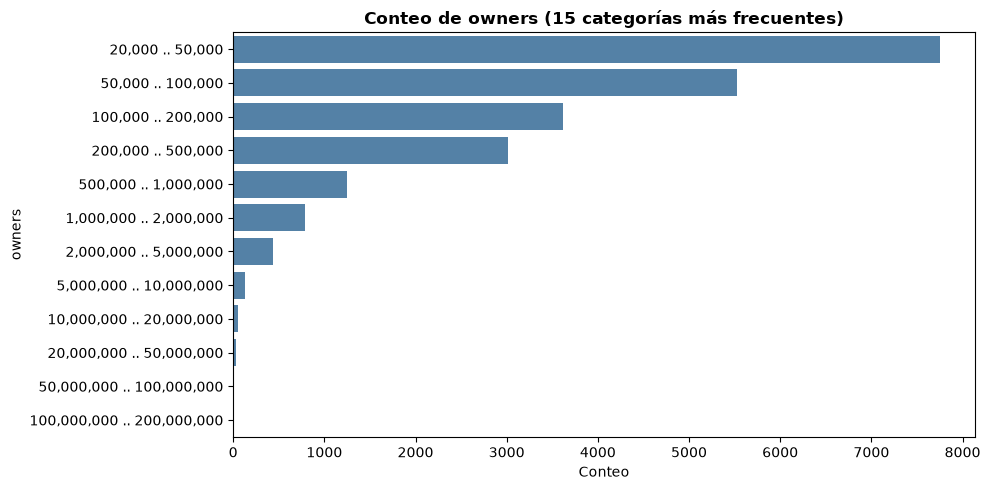


ANÁLISIS DE: IS_FREE

Cantidad de categorías: 2

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,False,19615,86.76
1,True,2948,13.04


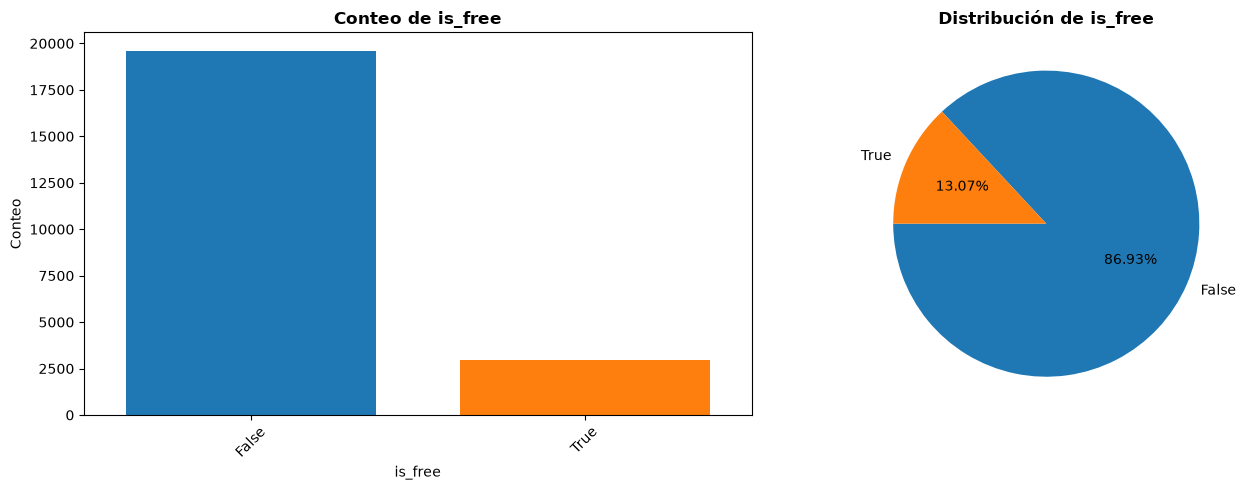


ANÁLISIS DE: PLATFORMS_WINDOWS

Cantidad de categorías: 2

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,True,22557,99.77
1,False,6,0.03


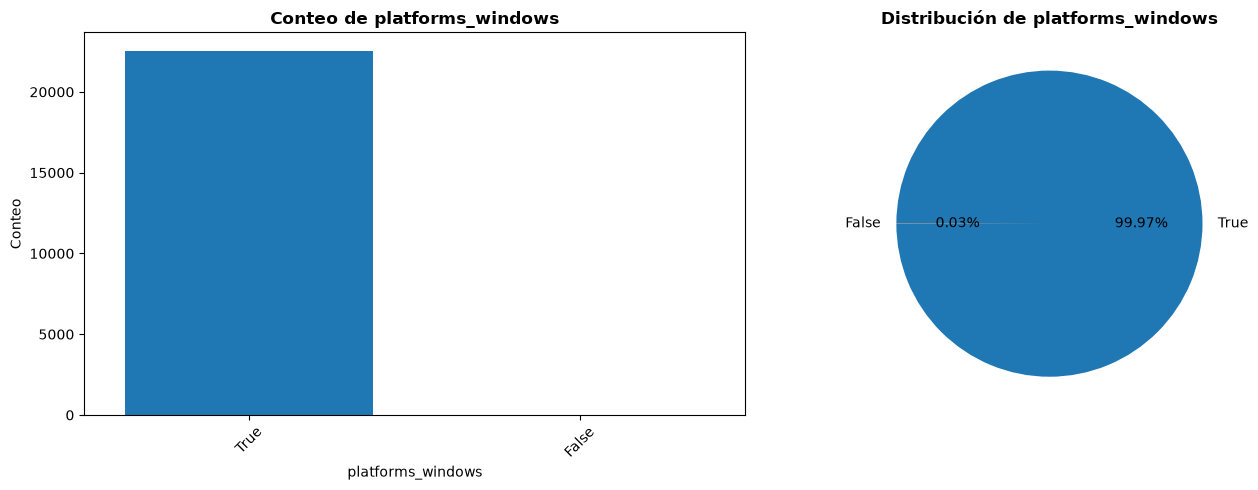


ANÁLISIS DE: PLATFORMS_MAC

Cantidad de categorías: 2

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,False,16490,72.94
1,True,6073,26.86


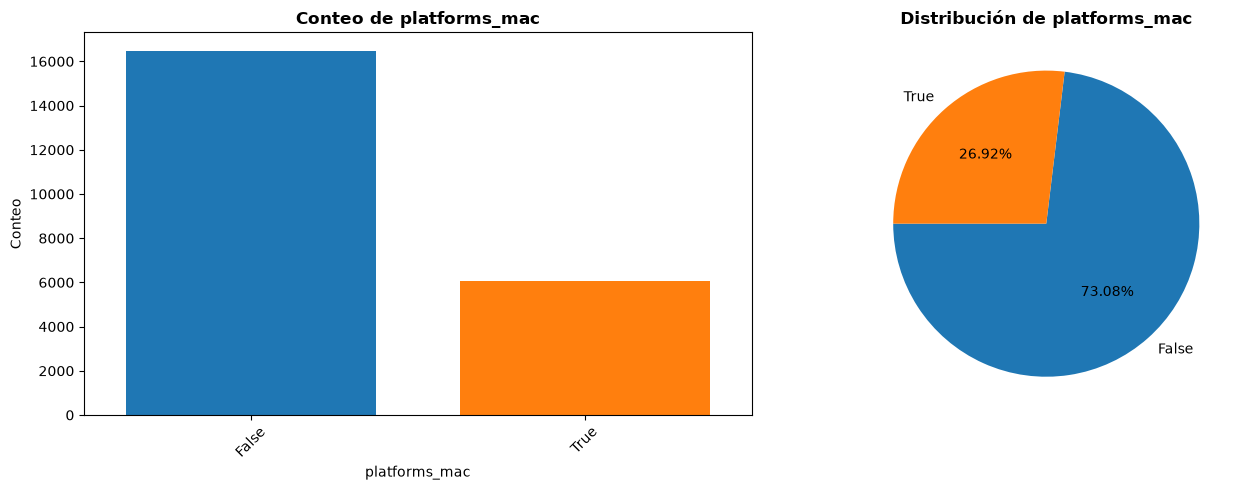


ANÁLISIS DE: PLATFORMS_LINUX

Cantidad de categorías: 2

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,False,18470,81.7
1,True,4093,18.1


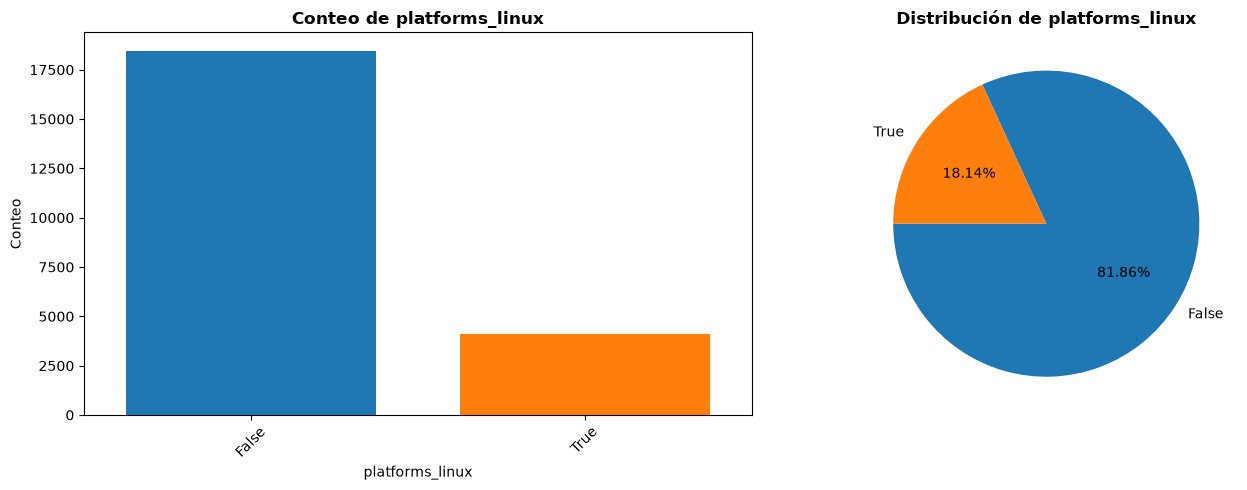


ANÁLISIS DE: GENERO_PRINCIPAL

Cantidad de categorías: 33

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Action,10038,44.40
1,Adventure,4998,22.11
2,Casual,2742,12.13
3,Indie,2083,9.21
4,Simulation,619,2.74
5,RPG,587,2.60
6,Strategy,487,2.15
7,Free To Play,328,1.45
8,Racing,199,0.88
9,Massively Multiplayer,75,0.33


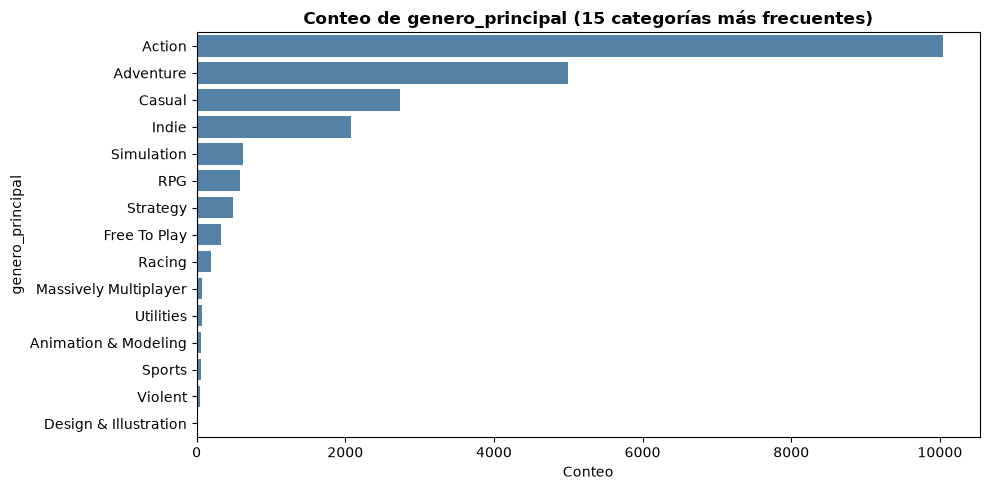

In [20]:
for col in columns_categorical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")

    num_categories = data[col].nunique()
    print(f"\nCantidad de categorías: {num_categories}")

    value_counts = data[col].value_counts()
    percentage = (value_counts / len(data) * 100).round(2)

    table = pd.DataFrame({
        'Categoría': value_counts.index,
        'Conteo': value_counts.values,
        'Porcentaje (%)': percentage.values
    })
    print("\nTabla de conteo y porcentajes:")
    display(table)

    if num_categories < 10:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors_array = plt.cm.tab10(range(num_categories))

        sns.countplot(data=data, x=col, ax=axes[0],
                      order=value_counts.index, legend=False, width=0.75)
        for i, patch in enumerate(axes[0].patches):
            patch.set_facecolor(colors_array[i])
        axes[0].set_title(f'Conteo de {col}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel(col, fontsize=10)
        axes[0].set_ylabel('Conteo', fontsize=10)
        axes[0].tick_params(axis='x', rotation=45)

        axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.2f%%',
                    startangle=180, colors=colors_array)
        axes[1].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()
    else:
        top = value_counts.head(15)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top.values, y=top.index.astype(str), color='steelblue')
        plt.title(f'Conteo de {col} (15 categorías más frecuentes)',
                  fontsize=12, fontweight='bold')
        plt.xlabel('Conteo', fontsize=10)
        plt.ylabel(col, fontsize=10)
        plt.tight_layout()
        plt.show()

## Numérico

In [21]:
data[columns_numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
positive,22608.0,5511.022116,63700.816936,0.0,50.000,293.00,1340.00,7642084.00
negative,22608.0,895.884377,12093.878535,0.0,15.000,76.00,272.00,1173003.00
discount,22608.0,6.343197,20.315025,0.0,0.000,0.00,0.00,100.00
ccu,22608.0,252.630839,7512.242873,0.0,0.000,1.00,7.00,1013936.00
required_age,22563.0,0.629039,3.165003,0.0,0.000,0.00,0.00,19.00
metacritic_score,3672.0,74.412582,10.021224,20.0,69.000,76.00,81.00,97.00
recommendations,22563.0,5025.125825,50879.012546,0.0,0.000,206.00,1205.00,5211693.00
achievements,22563.0,35.004831,215.267215,0.0,0.000,14.00,34.00,9821.00
precio_usd,22608.0,9.076622,10.709231,0.0,0.990,4.99,13.99,199.99
precio_inicial_usd,22608.0,10.172702,11.557758,0.0,1.475,6.99,14.99,199.99



ANÁLISIS DE: POSITIVE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
positive,22608.0,5511.022116,63700.816936,0.0,50.0,293.0,1340.0,7642084.0


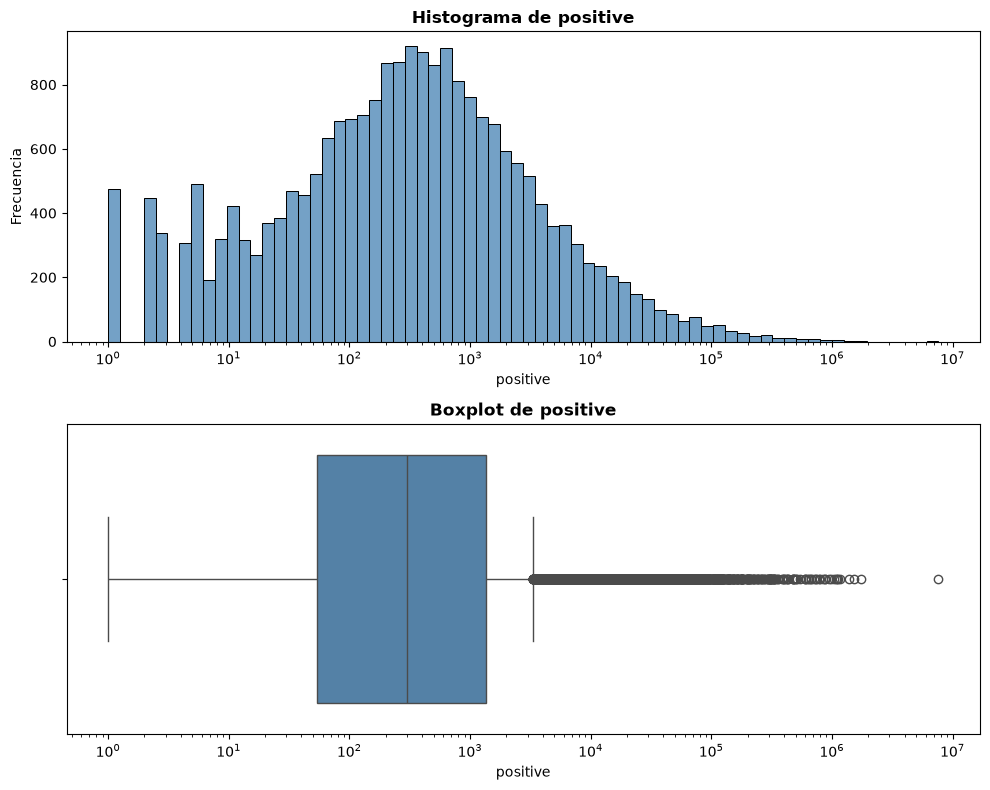


ANÁLISIS DE: NEGATIVE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
negative,22608.0,895.884377,12093.878535,0.0,15.0,76.0,272.0,1173003.0


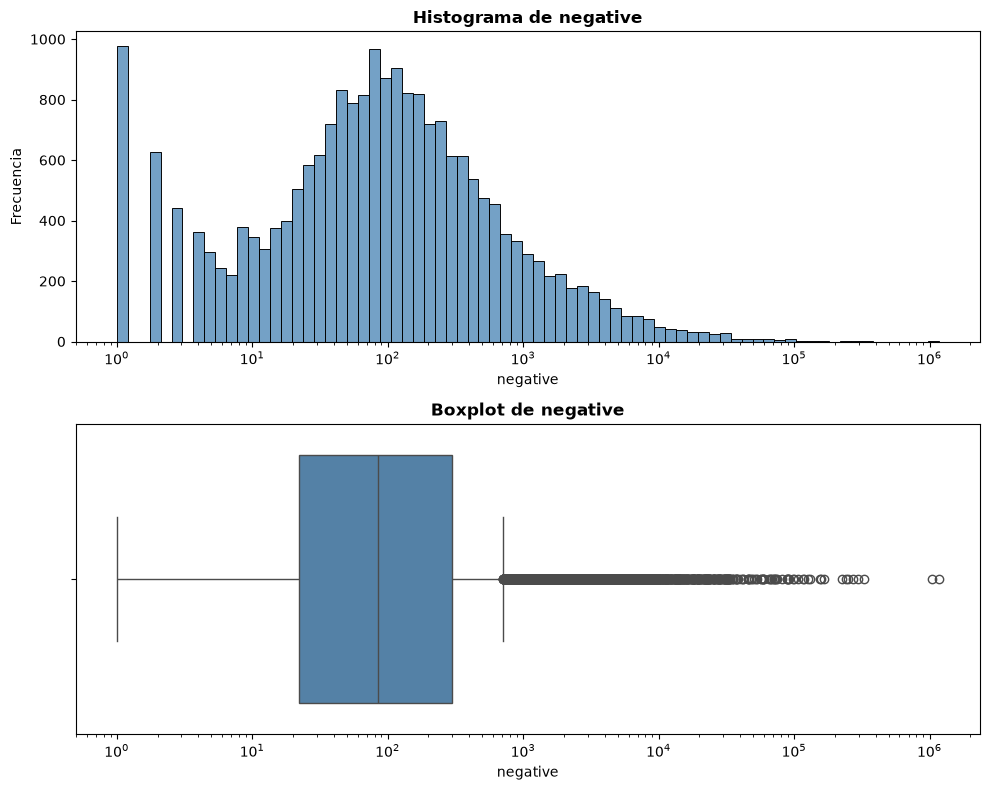


ANÁLISIS DE: DISCOUNT

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
discount,22608.0,6.343197,20.315025,0.0,0.0,0.0,0.0,100.0


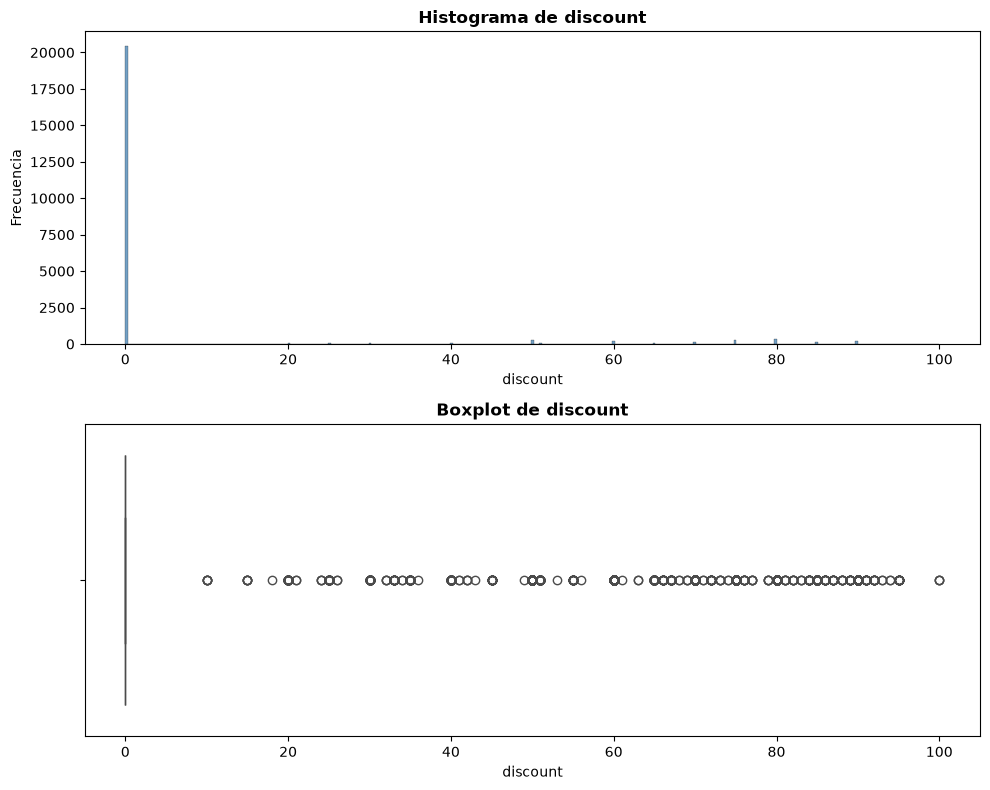


ANÁLISIS DE: CCU

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
ccu,22608.0,252.630839,7512.242873,0.0,0.0,1.0,7.0,1013936.0


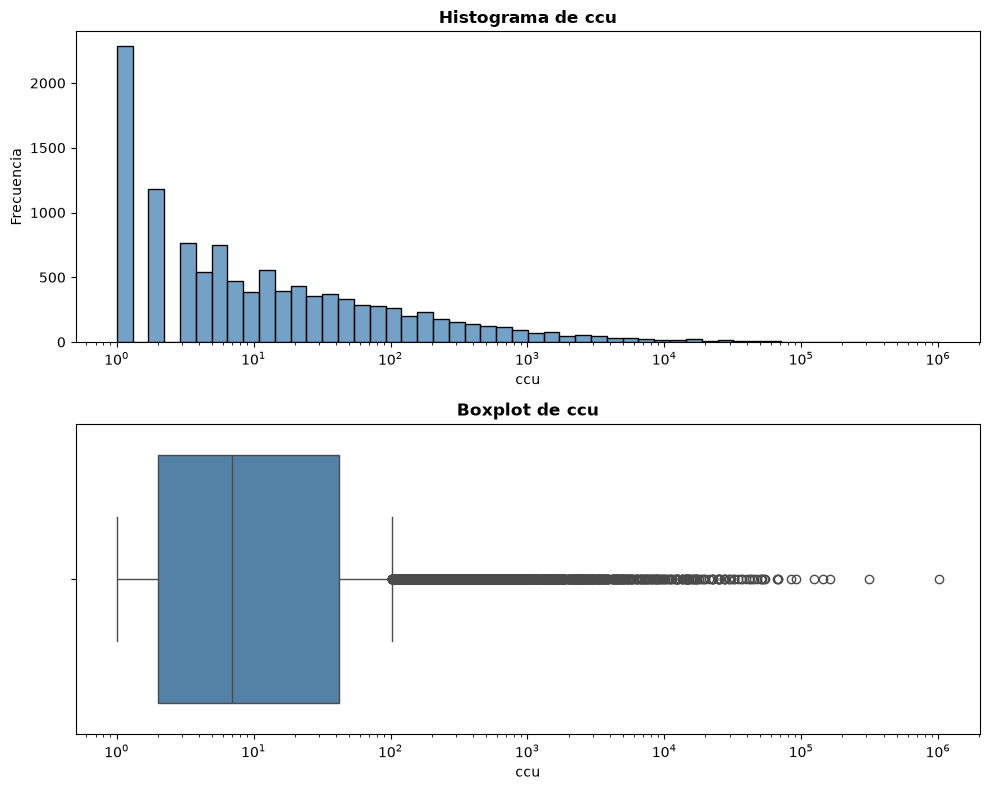


ANÁLISIS DE: REQUIRED_AGE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
required_age,22563.0,0.629039,3.165003,0.0,0.0,0.0,0.0,19.0


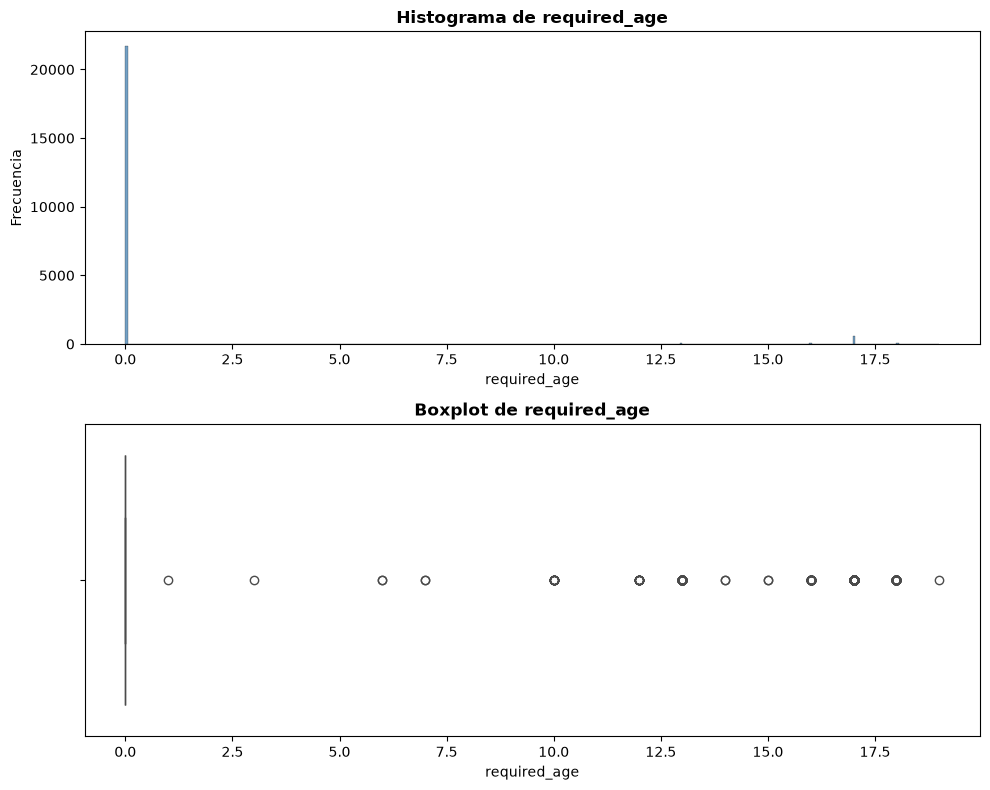


ANÁLISIS DE: METACRITIC_SCORE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
metacritic_score,3672.0,74.412582,10.021224,20.0,69.0,76.0,81.0,97.0


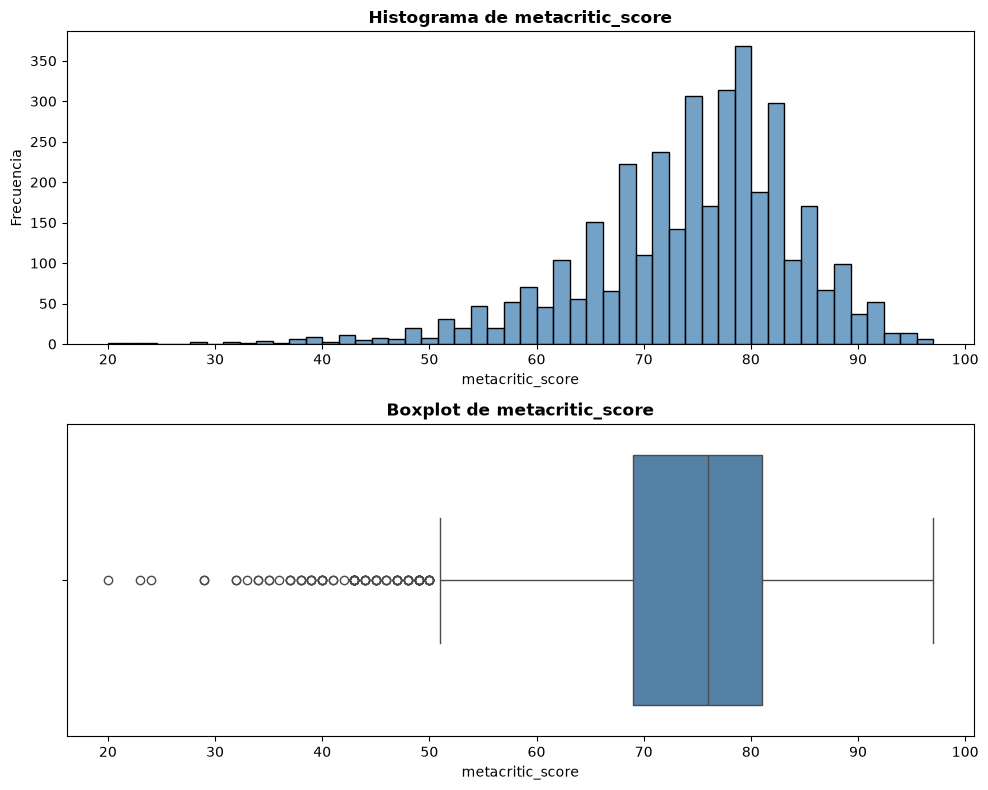


ANÁLISIS DE: RECOMMENDATIONS

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
recommendations,22563.0,5025.125825,50879.012546,0.0,0.0,206.0,1205.0,5211693.0


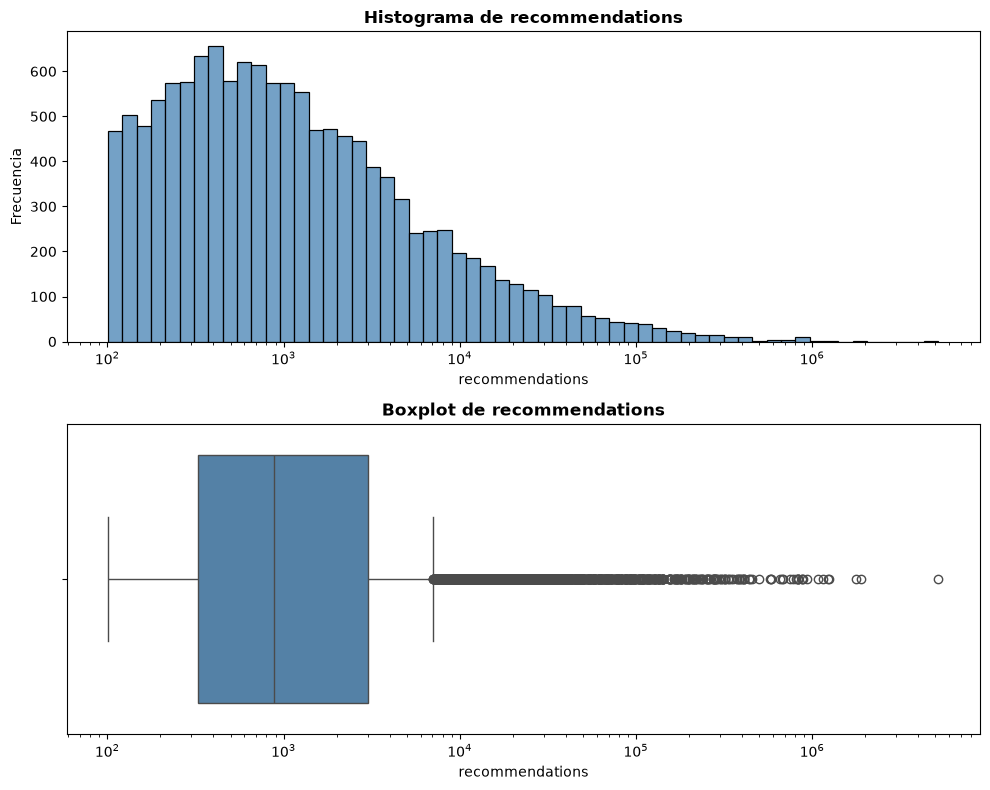


ANÁLISIS DE: ACHIEVEMENTS

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
achievements,22563.0,35.004831,215.267215,0.0,0.0,14.0,34.0,9821.0


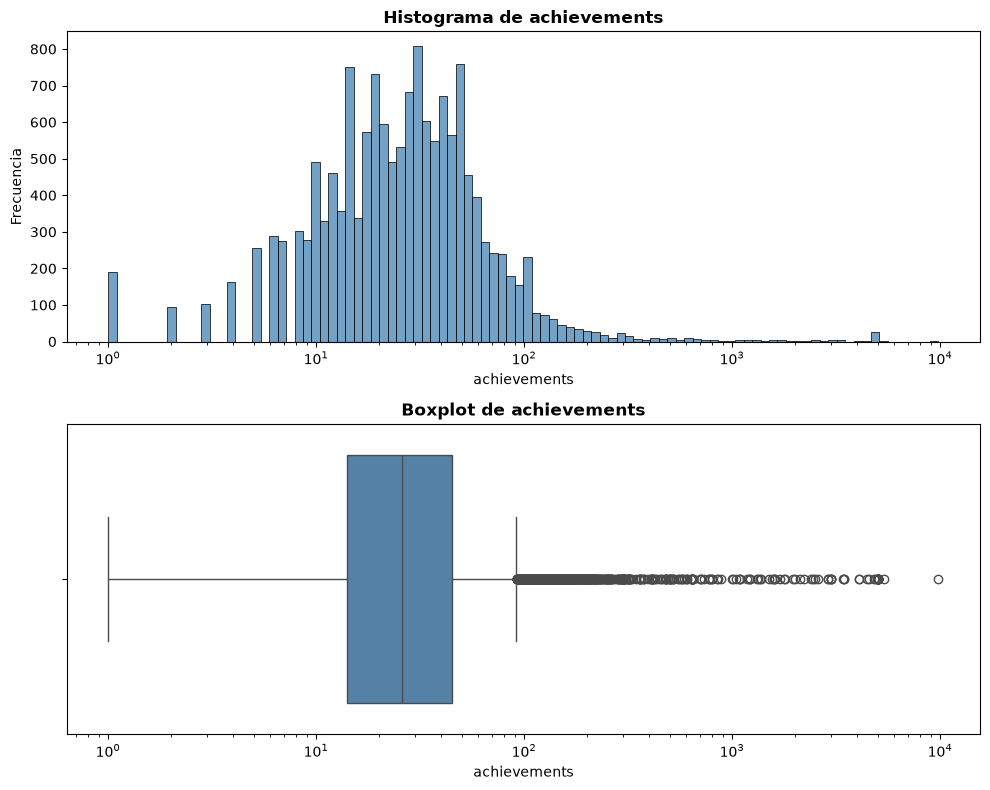


ANÁLISIS DE: PRECIO_USD

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
precio_usd,22608.0,9.076622,10.709231,0.0,0.99,4.99,13.99,199.99


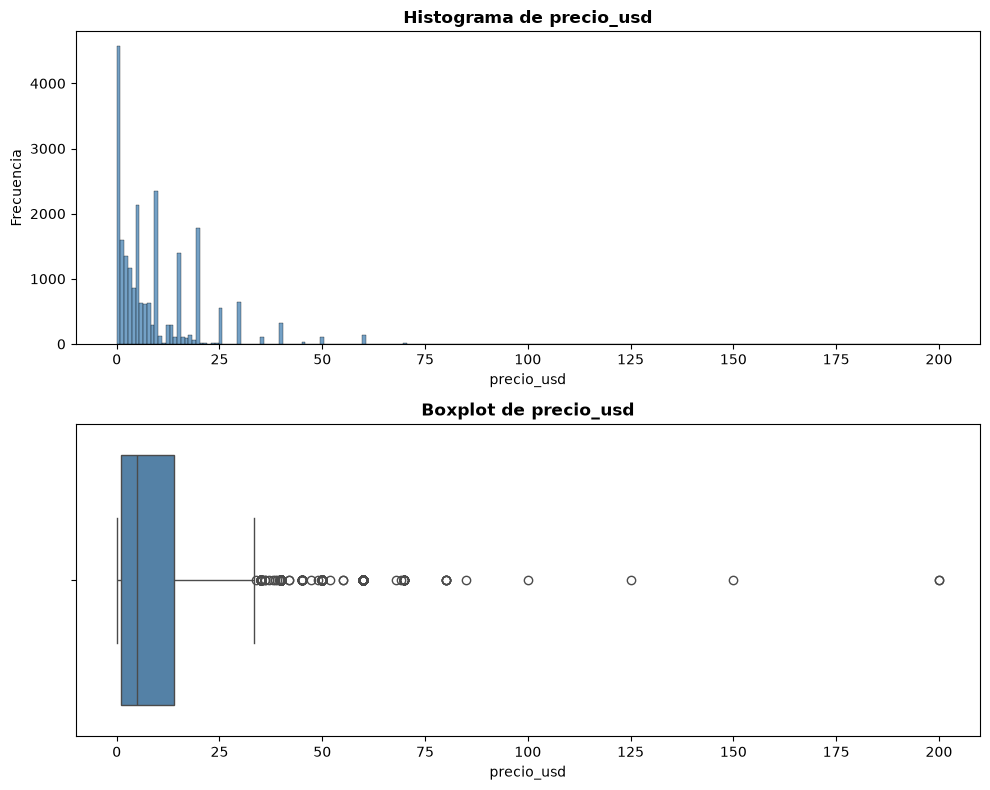


ANÁLISIS DE: PRECIO_INICIAL_USD

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
precio_inicial_usd,22608.0,10.172702,11.557758,0.0,1.475,6.99,14.99,199.99


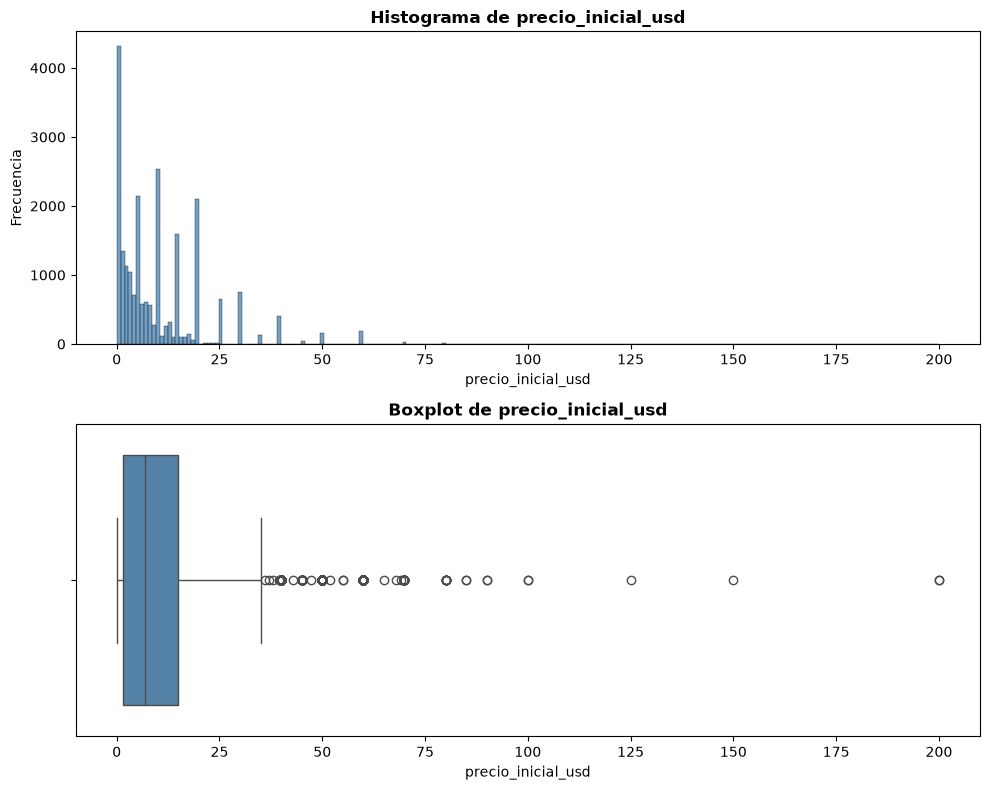


ANÁLISIS DE: ANIO_LANZAMIENTO

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
anio_lanzamiento,22492.0,2018.813222,3.965013,1997.0,2016.0,2019.0,2022.0,2026.0


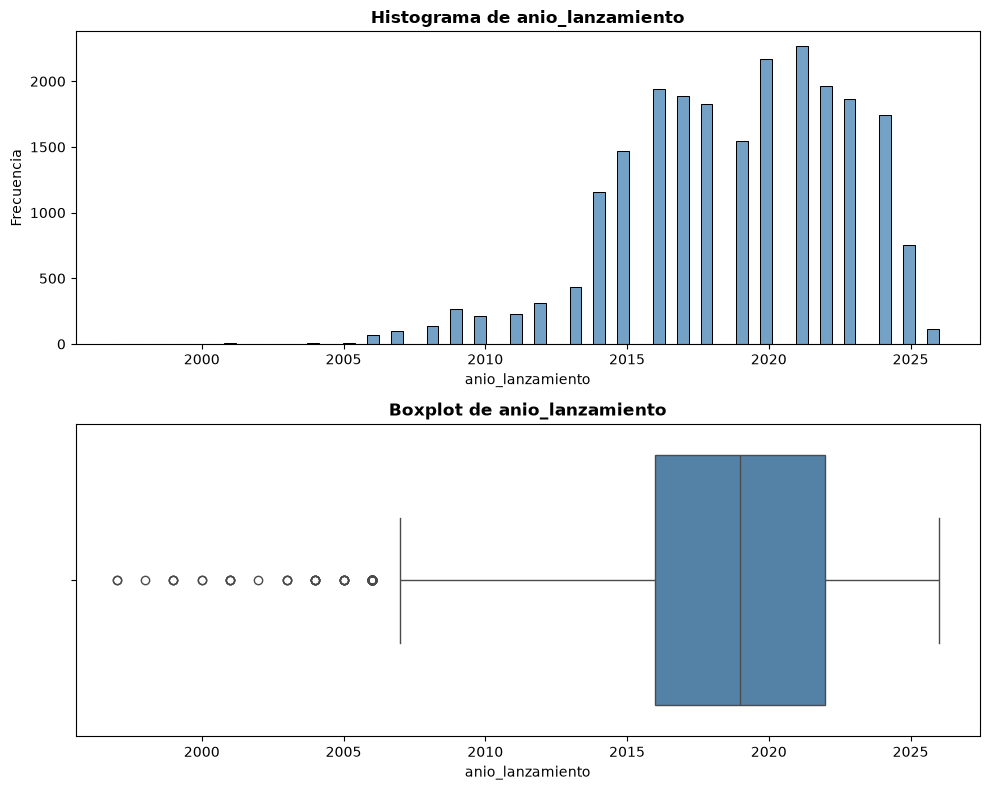


ANÁLISIS DE: TOTAL_RESENAS

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
total_resenas,22608.0,6406.906493,73809.213297,0.0,74.0,397.0,1653.0,8815087.0


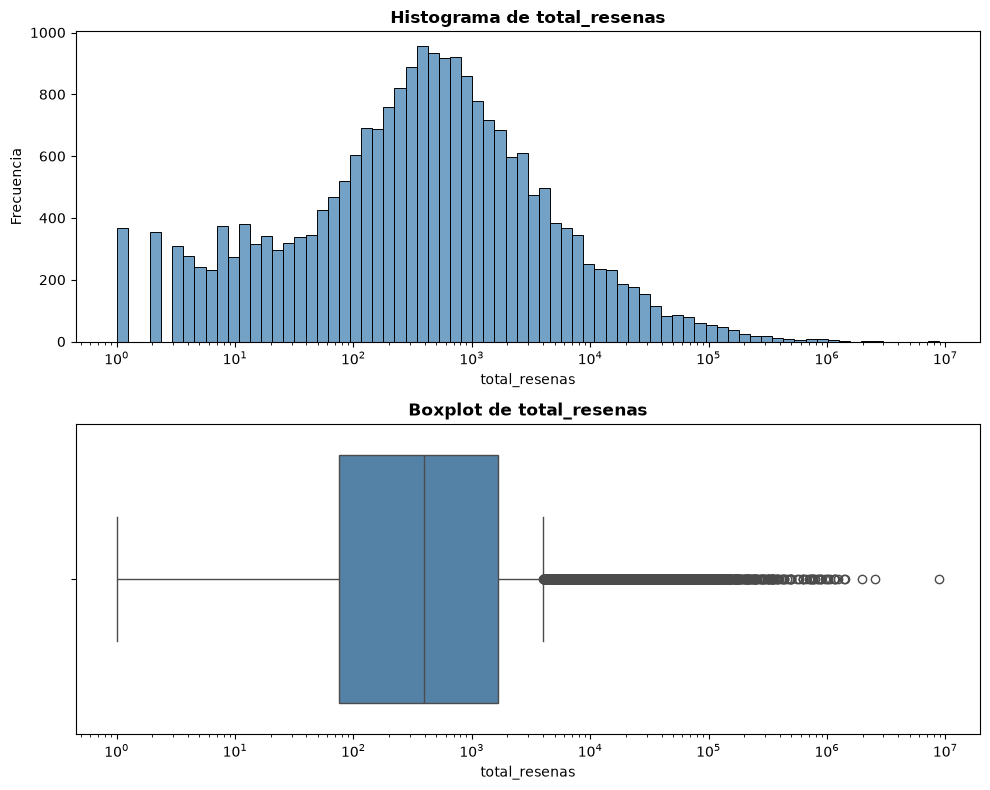


ANÁLISIS DE: PORCENTAJE_POSITIVO

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
porcentaje_positivo,22581.0,76.791969,18.391345,0.0,67.37,80.8,90.34,100.0


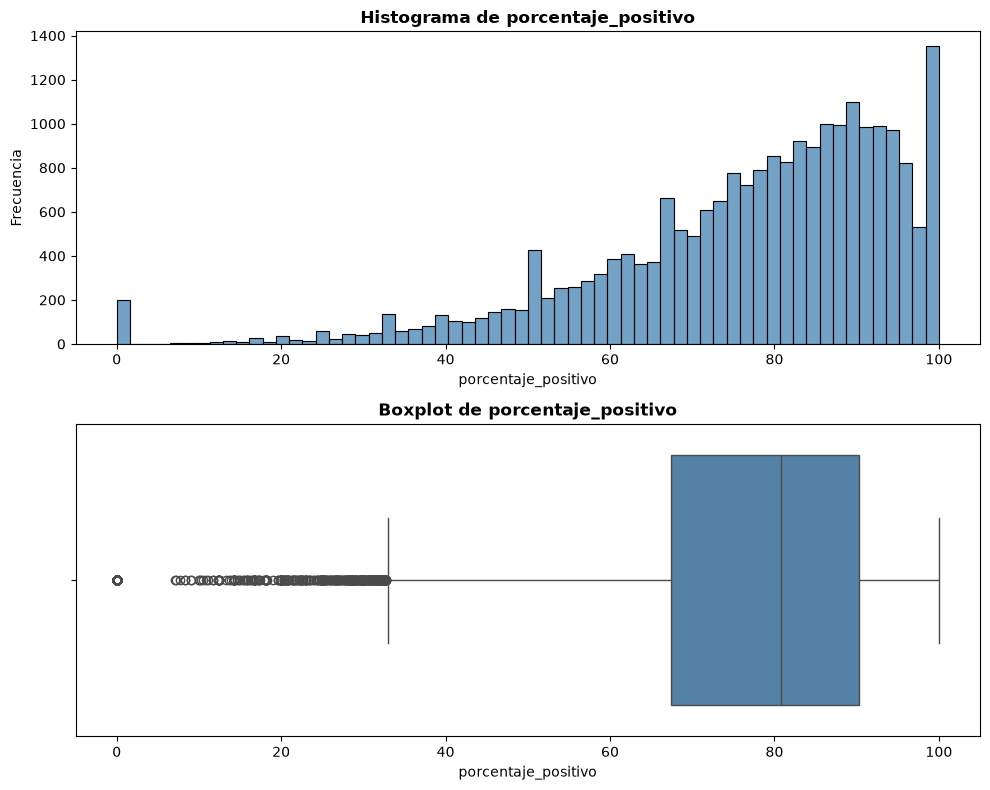


ANÁLISIS DE: N_PLATAFORMAS

Estadística descriptiva:


,count,unique,top,freq
n_plataformas,22563,3,1,15784


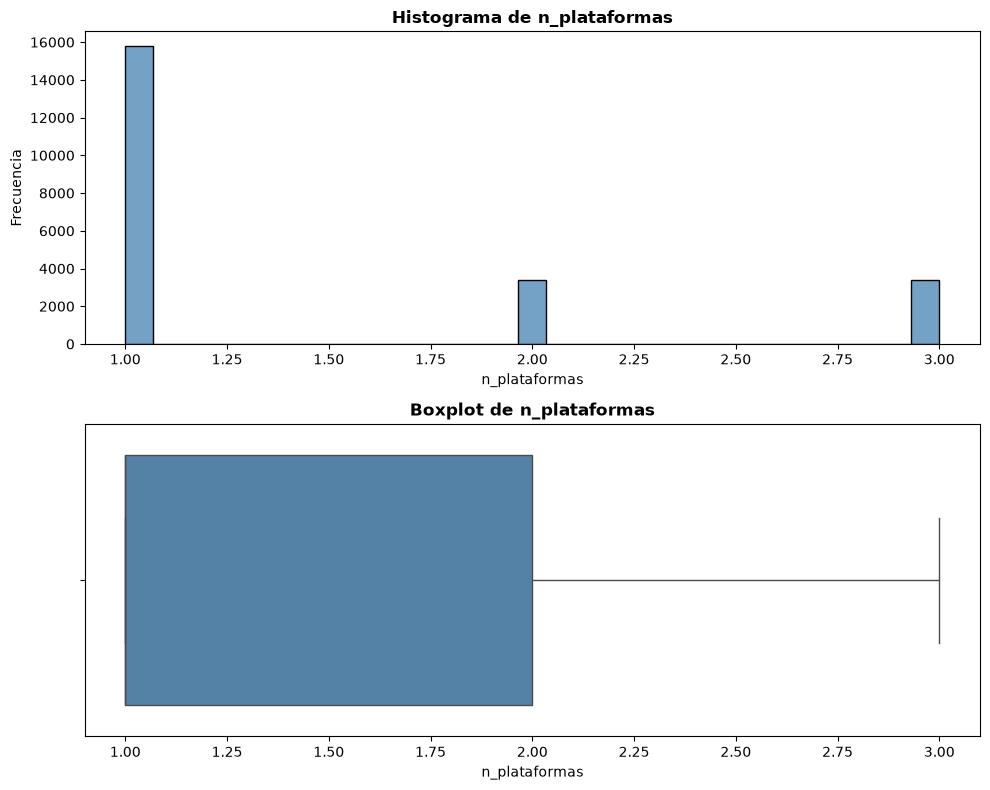

In [22]:
# Variables muy sesgadas: se grafican en escala logarítmica para poder leerlas
columnas_sesgadas = ['positive', 'negative', 'total_resenas', 'ccu',
                     'recommendations', 'achievements']

for col in columns_numerical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")

    stats = data[col].describe().to_frame().T
    print("\nEstadística descriptiva:")
    display(stats)

    usar_log = col in columnas_sesgadas
    valores = data[data[col] > 0][col] if usar_log else data[col]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    sns.histplot(x=valores, ax=axes[0], color='steelblue', log_scale=usar_log)
    axes[0].set_title(f'Histograma de {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=10)
    axes[0].set_ylabel('Frecuencia', fontsize=10)

    sns.boxplot(x=valores, ax=axes[1], color='steelblue')
    if usar_log:
        axes[1].set_xscale('log')
    axes[1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=10)

    plt.tight_layout()
    plt.show()

## Temporal

Fecha mínima: 1997-06-30 00:00:00
Fecha máxima: 2026-08-05 00:00:00

Fecha con más lanzamientos: 2021-01-28 (28 juegos)


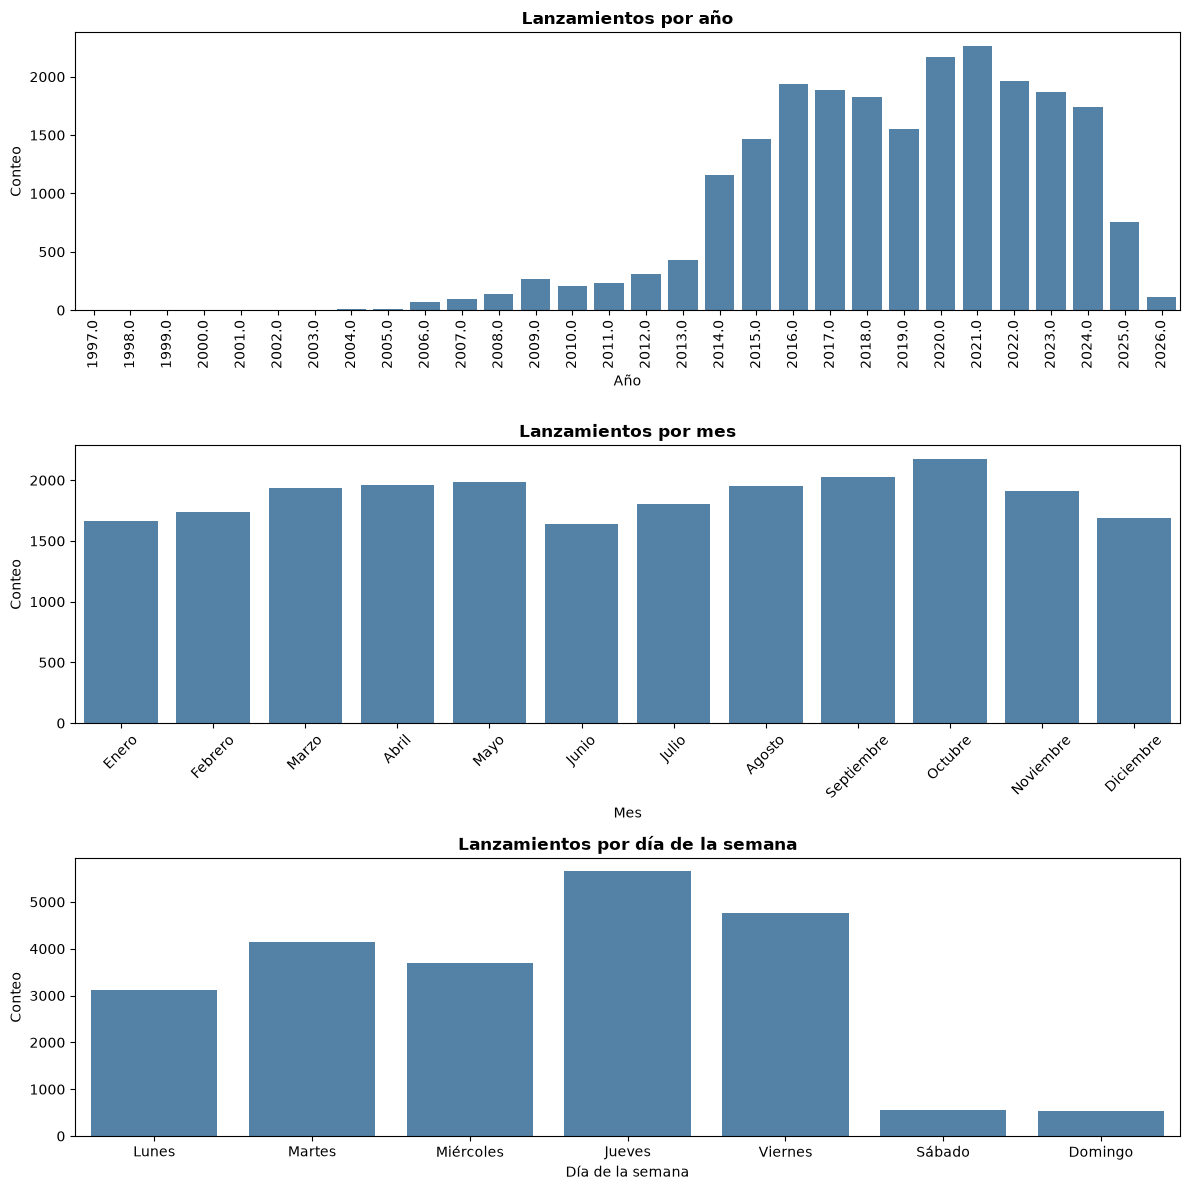

In [23]:
col = 'fecha_lanzamiento'

print(f"Fecha mínima: {data[col].min()}")
print(f"Fecha máxima: {data[col].max()}")

lanzamientos_por_fecha = data[col].value_counts()
print(f"\nFecha con más lanzamientos: {lanzamientos_por_fecha.index[0].date()} "
      f"({lanzamientos_por_fecha.iloc[0]} juegos)")

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

sns.countplot(x=data[col].dt.year, ax=axes[0], color='steelblue')
axes[0].set_title('Lanzamientos por año', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año', fontsize=10)
axes[0].set_ylabel('Conteo', fontsize=10)
axes[0].tick_params(axis='x', rotation=90)

meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
         'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
sns.countplot(x=data[col].dt.month, ax=axes[1], color='steelblue')
axes[1].set_title('Lanzamientos por mes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=10)
axes[1].set_ylabel('Conteo', fontsize=10)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(meses, rotation=45)

dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
sns.countplot(x=data[col].dt.dayofweek, ax=axes[2], color='steelblue')
axes[2].set_title('Lanzamientos por día de la semana', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Día de la semana', fontsize=10)
axes[2].set_ylabel('Conteo', fontsize=10)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dias)

plt.tight_layout()
plt.show()

# Análisis bivariante

## Numérico

In [24]:
data[columns_numerical].corr().round(2)

,positive,negative,discount,ccu,required_age,metacritic_score,recommendations,achievements,precio_usd,precio_inicial_usd,anio_lanzamiento,total_resenas,porcentaje_positivo,n_plataformas
positive,1.00,0.81,0.02,0.88,0.10,0.20,0.96,0.02,0.07,0.08,-0.03,1.00,0.05,0.02
negative,0.81,1.00,0.01,0.85,0.10,0.11,0.78,0.01,0.05,0.06,-0.02,0.86,-0.00,-0.00
discount,0.02,0.01,1.00,0.00,0.09,0.03,0.03,0.02,-0.12,0.19,-0.01,0.02,0.02,-0.01
ccu,0.88,0.85,0.00,1.00,0.04,0.11,0.81,0.01,0.03,0.03,-0.01,0.90,0.01,0.01
required_age,0.10,0.10,0.09,0.04,1.00,0.07,0.12,0.00,0.18,0.22,-0.13,0.10,0.02,-0.05
metacritic_score,0.20,0.11,0.03,0.11,0.07,1.00,0.19,0.09,0.20,0.24,0.15,0.20,0.59,0.06
recommendations,0.96,0.78,0.03,0.81,0.12,0.19,1.00,0.02,0.10,0.12,-0.02,0.96,0.06,0.02
achievements,0.02,0.01,0.02,0.01,0.00,0.09,0.02,1.00,0.01,0.01,-0.01,0.02,0.01,0.01
precio_usd,0.07,0.05,-0.12,0.03,0.18,0.20,0.10,0.01,1.00,0.92,0.11,0.06,0.11,-0.01
precio_inicial_usd,0.08,0.06,0.19,0.03,0.22,0.24,0.12,0.01,0.92,1.00,0.12,0.08,0.12,-0.02


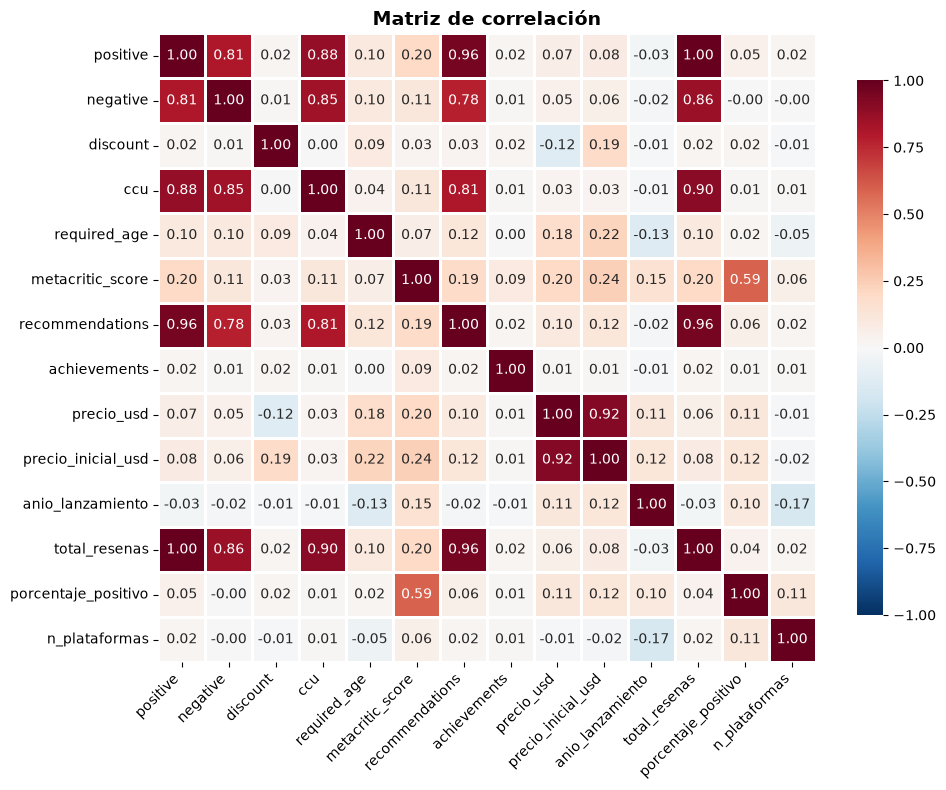

In [25]:
corr_matrix = data[columns_numerical].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=2,
    linecolor='white',
    cbar_kws={'shrink': 0.85}
)
plt.title('Matriz de correlación', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

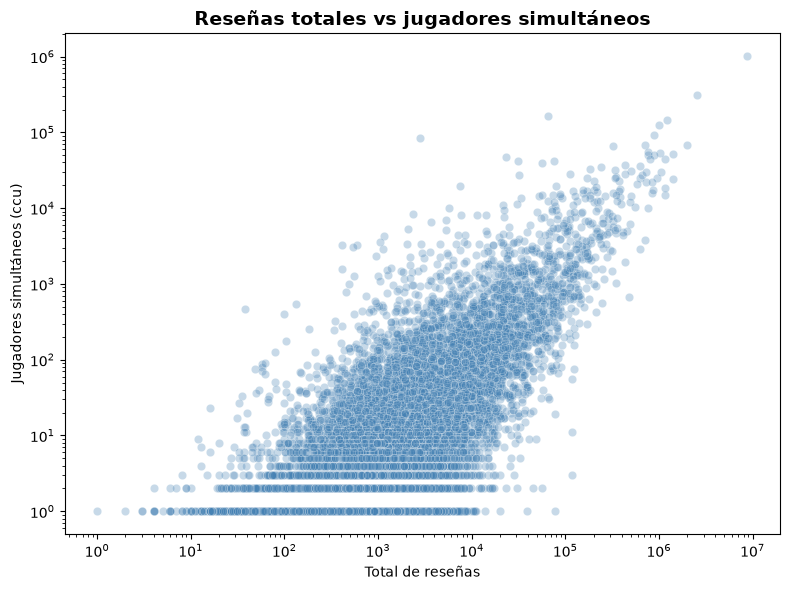

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='total_resenas', y='ccu', alpha=0.3, color='steelblue')
plt.xscale('log')
plt.yscale('log')
plt.title('Reseñas totales vs jugadores simultáneos', fontsize=14, fontweight='bold')
plt.xlabel('Total de reseñas', fontsize=10)
plt.ylabel('Jugadores simultáneos (ccu)', fontsize=10)
plt.tight_layout()
plt.show()

## Categórico

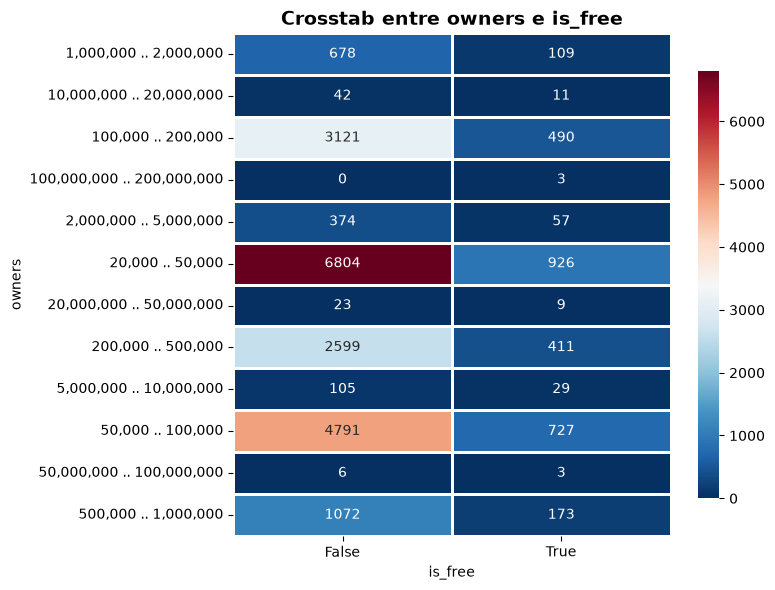

In [27]:
crosstab = pd.crosstab(data['owners'], data['is_free'])

plt.figure(figsize=(8, 6))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='d',
    cmap='RdBu_r',
    linewidths=2,
    linecolor='white',
    cbar_kws={'shrink': 0.85}
)
plt.title('Crosstab entre owners e is_free', fontsize=14, fontweight='bold')
plt.xlabel('is_free', fontsize=10)
plt.ylabel('owners', fontsize=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

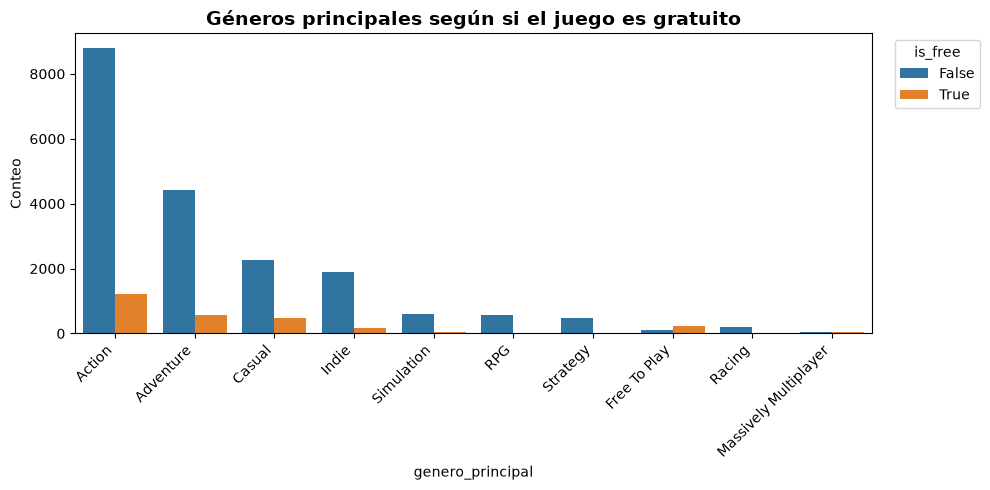

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=data,
    x='genero_principal',
    hue='is_free',
    order=data['genero_principal'].value_counts().index[:10],
    palette='tab10'
)
plt.title('Géneros principales según si el juego es gratuito', fontsize=14, fontweight='bold')
plt.xlabel('genero_principal', fontsize=10)
plt.ylabel('Conteo', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.legend(title='is_free', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Numérico + categórico

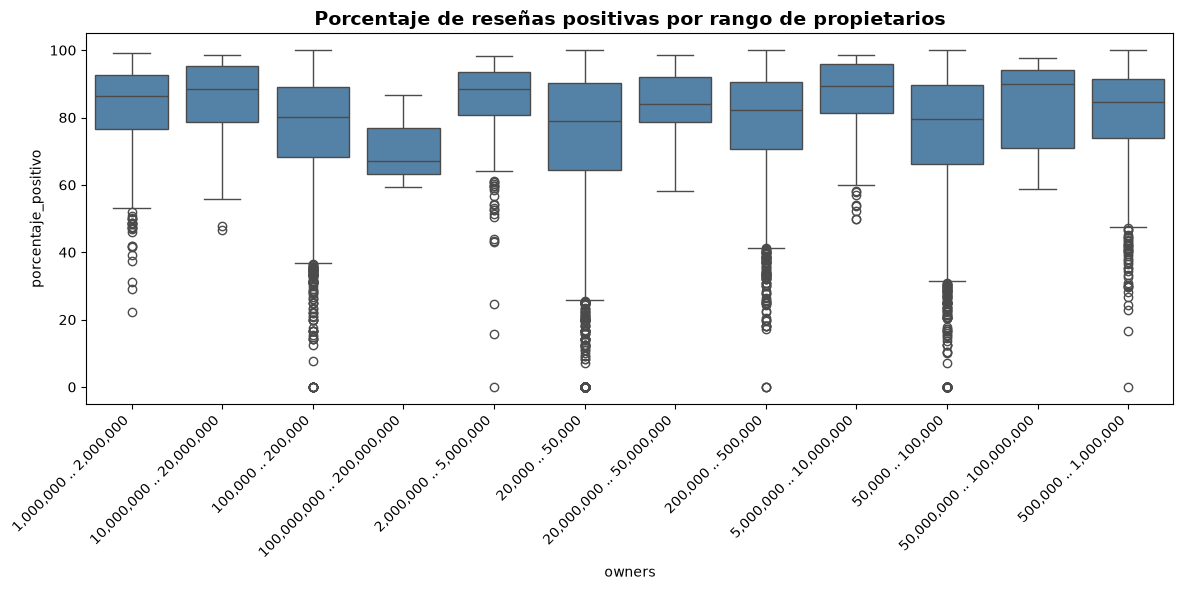

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='owners', y='porcentaje_positivo', color='steelblue')
plt.title('Porcentaje de reseñas positivas por rango de propietarios',
          fontsize=14, fontweight='bold')
plt.xlabel('owners', fontsize=10)
plt.ylabel('porcentaje_positivo', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

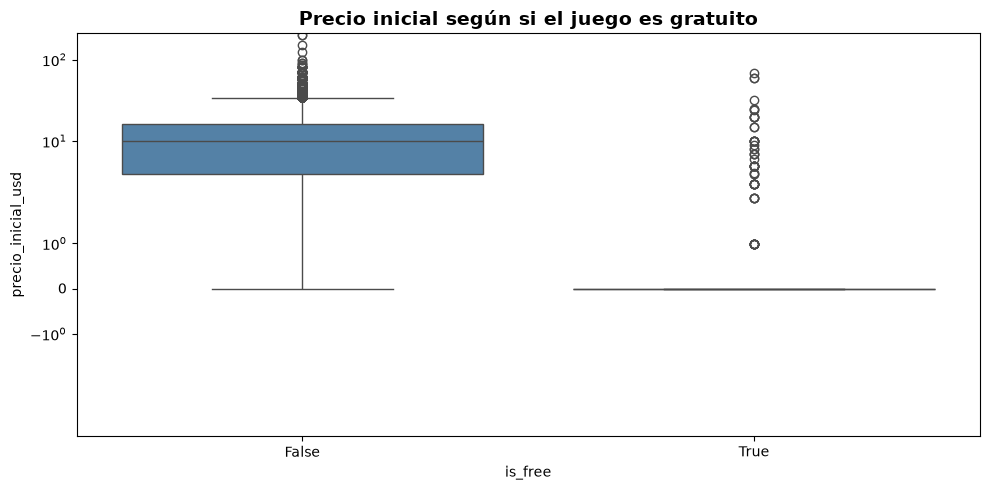

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='is_free', y='precio_inicial_usd', color='steelblue')
plt.yscale('symlog')
plt.title('Precio inicial según si el juego es gratuito', fontsize=14, fontweight='bold')
plt.xlabel('is_free', fontsize=10)
plt.ylabel('precio_inicial_usd', fontsize=10)
plt.tight_layout()
plt.show()

## Temporal + numérico

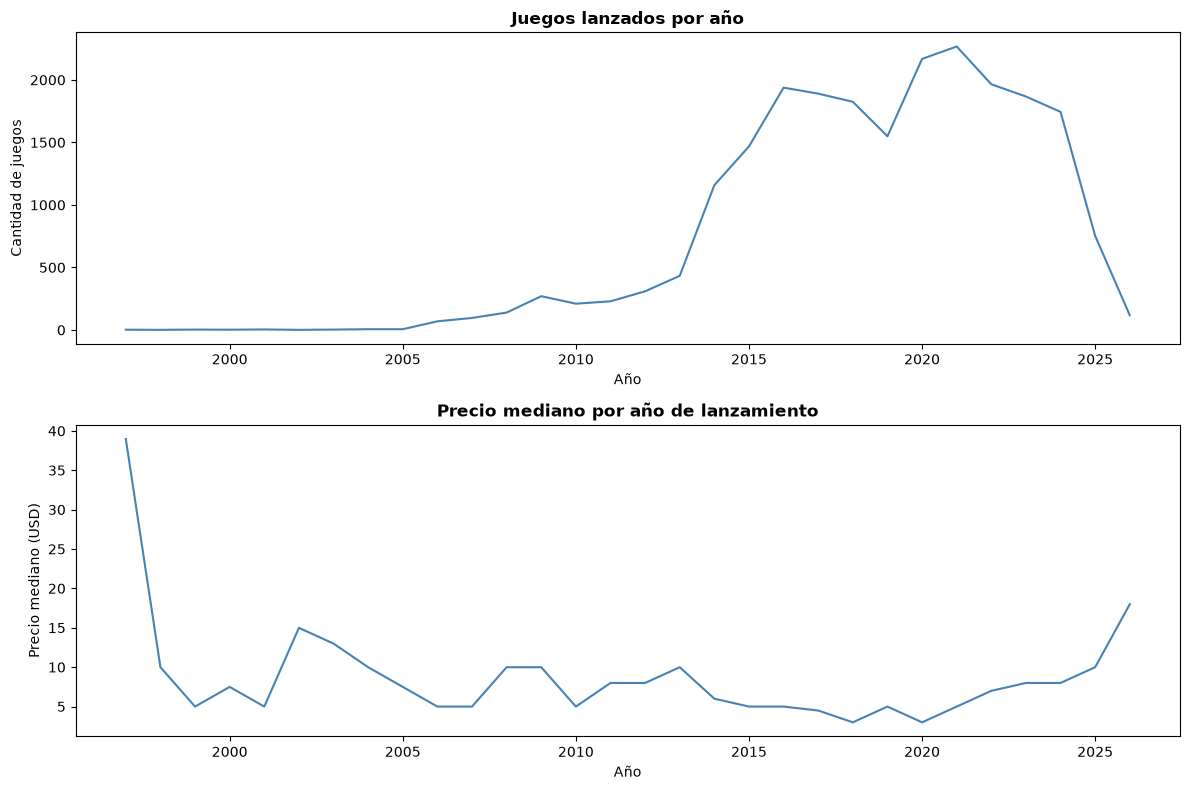

In [31]:
evolucion = data.groupby('anio_lanzamiento').agg(
    juegos=('name', 'count'),
    precio_mediano=('precio_usd', 'median')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(data=evolucion, x='anio_lanzamiento', y='juegos', ax=axes[0], color='steelblue')
axes[0].set_title('Juegos lanzados por año', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año', fontsize=10)
axes[0].set_ylabel('Cantidad de juegos', fontsize=10)

sns.lineplot(data=evolucion, x='anio_lanzamiento', y='precio_mediano', ax=axes[1], color='steelblue')
axes[1].set_title('Precio mediano por año de lanzamiento', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año', fontsize=10)
axes[1].set_ylabel('Precio mediano (USD)', fontsize=10)

plt.tight_layout()
plt.show()

# Preguntas de análisis

## 1. ¿Coinciden la crítica especializada y los jugadores al valorar un juego?

In [32]:
comparacion = data.dropna(subset=['metacritic_score', 'porcentaje_positivo'])

print(f"Juegos con puntuación de Metacritic: {len(comparacion)} de {len(data)}")
print(f"Correlación: {comparacion['metacritic_score'].corr(comparacion['porcentaje_positivo']).round(3)}")

rangos_metacritic = pd.cut(comparacion['metacritic_score'],
                           bins=[0, 59, 69, 79, 89, 100],
                           labels=['<60', '60-69', '70-79', '80-89', '90-100'])

tabla = comparacion.groupby(rangos_metacritic, observed=True).agg(
    juegos=('name', 'count'),
    porcentaje_positivo_medio=('porcentaje_positivo', 'mean')
).round(2)
tabla

Juegos con puntuación de Metacritic: 3668 de 22608
Correlación: 0.591


,juegos,porcentaje_positivo_medio
metacritic_score,,
<60,300,62.29
60-69,673,72.97
70-79,1435,81.63
80-89,1137,87.96
90-100,123,91.00


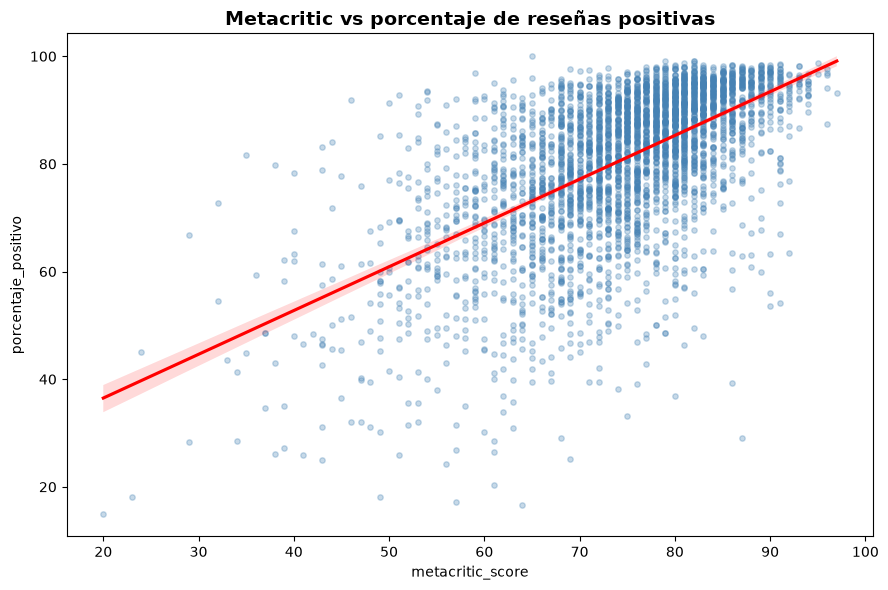

In [33]:
plt.figure(figsize=(9, 6))
sns.regplot(data=comparacion, x='metacritic_score', y='porcentaje_positivo',
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'red'})
plt.title('Metacritic vs porcentaje de reseñas positivas', fontsize=14, fontweight='bold')
plt.xlabel('metacritic_score', fontsize=10)
plt.ylabel('porcentaje_positivo', fontsize=10)
plt.tight_layout()
plt.show()

**Conclusión.** La correlación es 0.591, es decir positiva pero moderada. La tendencia sí coincide:
los juegos con menos de 60 puntos en Metacritic tienen en promedio 62.29% de reseñas positivas y los
que superan los 90 llegan a 91.00%. Sin embargo, una correlación de 0.591 indica que crítica y
jugadores no siempre valoran igual un mismo juego. Además, solo 3668 de los 22608 juegos tienen
puntuación de Metacritic, de modo que la crítica cubre una parte pequeña del catálogo.

## 2. ¿Qué géneros tienen mejor recepción entre los jugadores?

In [34]:
recepcion_genero = data.dropna(subset=['porcentaje_positivo']).groupby(
    'genero_principal', observed=True).agg(
    juegos=('name', 'count'),
    porcentaje_positivo_medio=('porcentaje_positivo', 'mean'),
    resenas_medianas=('total_resenas', 'median')
).round(2)

recepcion_genero = recepcion_genero[recepcion_genero['juegos'] >= 50]
recepcion_genero = recepcion_genero.sort_values('porcentaje_positivo_medio', ascending=False)
recepcion_genero

,juegos,porcentaje_positivo_medio,resenas_medianas
genero_principal,,,
Adventure,4993,79.67,328.0
RPG,587,78.22,693.0
Indie,2080,77.73,397.5
Animation & Modeling,56,76.82,374.5
Casual,2740,76.76,250.0
Strategy,485,75.89,461.0
Action,10027,75.89,452.0
Racing,198,75.70,1322.0
Utilities,71,72.94,494.0


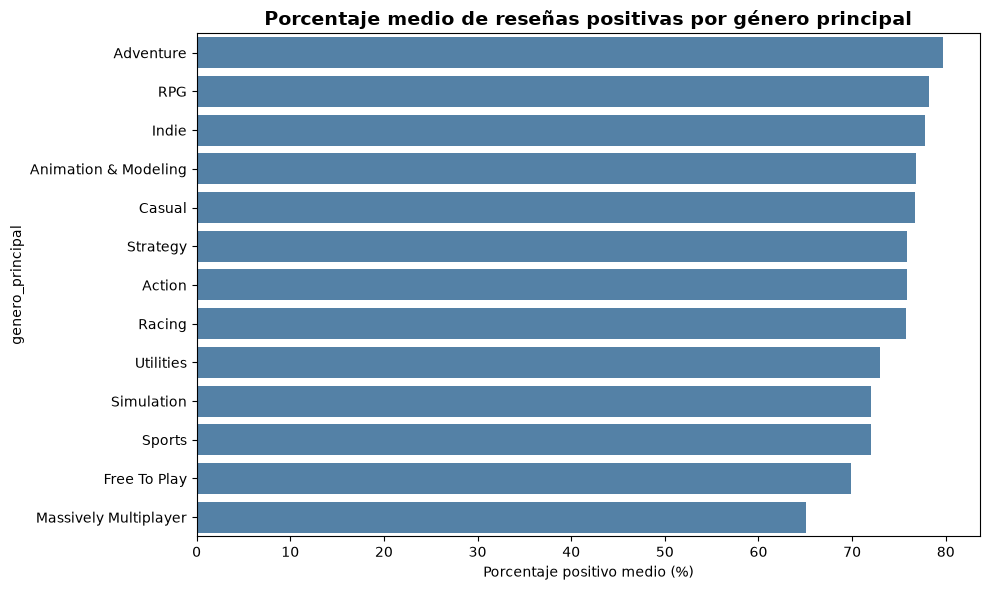

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x=recepcion_genero['porcentaje_positivo_medio'],
            y=recepcion_genero.index.astype(str), color='steelblue')
plt.title('Porcentaje medio de reseñas positivas por género principal',
          fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje positivo medio (%)', fontsize=10)
plt.ylabel('genero_principal', fontsize=10)
plt.tight_layout()
plt.show()

**Conclusión.** Entre los géneros con al menos 50 juegos, Adventure es el mejor valorado (79.67%),
seguido de RPG (78.22%) e Indie (77.73%). Los peores son Massively Multiplayer (65.05%) y Free To Play
(69.90%). La diferencia entre el mejor y el peor género es de casi 15 puntos porcentuales. Llama la
atención que Massively Multiplayer tenga la peor valoración a pesar de contar con una mediana de 1136
reseñas, una de las más altas: son juegos que llegan a mucho público pero reciben peores críticas.

## 3. ¿El precio de un juego se relaciona con su valoración y su alcance?

In [36]:
rangos_precio = pd.cut(data['precio_usd'],
                       bins=[-0.01, 0, 4.99, 9.99, 19.99, 39.99, 200],
                       labels=['Gratis', '0.01-4.99', '5-9.99', '10-19.99', '20-39.99', '40+'])

tabla_precio = data.groupby(rangos_precio, observed=True).agg(
    juegos=('name', 'count'),
    porcentaje_positivo_medio=('porcentaje_positivo', 'mean'),
    resenas_medianas=('total_resenas', 'median'),
    ccu_mediano=('ccu', 'median')
).round(2)
tabla_precio

,juegos,porcentaje_positivo_medio,resenas_medianas,ccu_mediano
precio_usd,,,,
Gratis,4313,73.55,328.0,0.0
0.01-4.99,7305,74.60,136.0,0.0
5-9.99,4563,78.08,354.0,1.0
10-19.99,4386,80.72,916.0,3.0
20-39.99,1722,80.53,2780.5,26.0
40+,318,78.32,6360.5,127.5


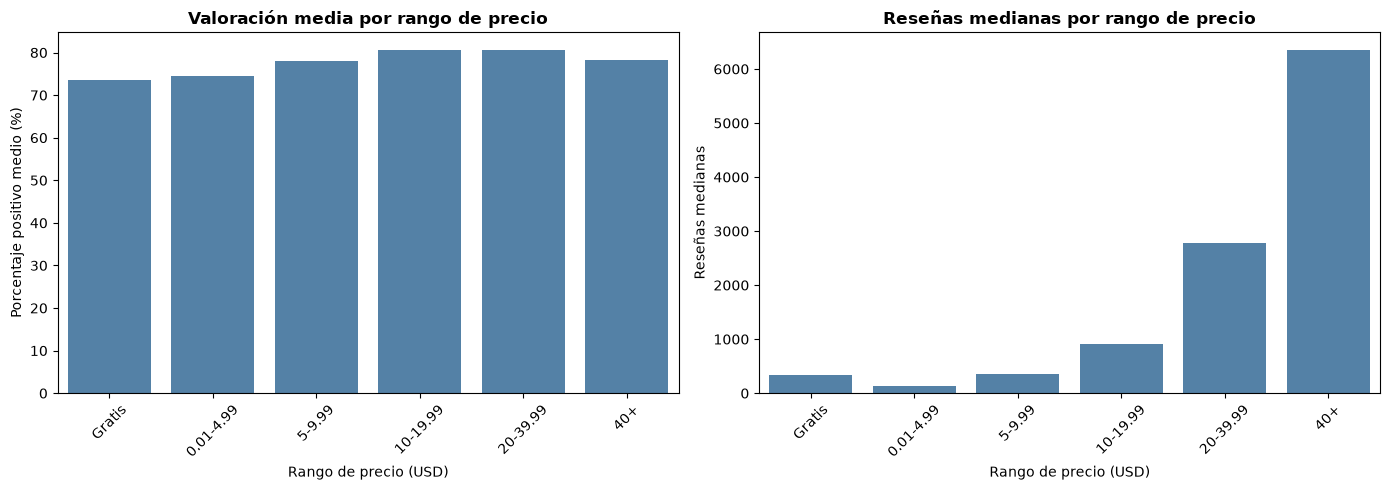

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=tabla_precio.reset_index(), x='precio_usd',
            y='porcentaje_positivo_medio', ax=axes[0], color='steelblue')
axes[0].set_title('Valoración media por rango de precio', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rango de precio (USD)', fontsize=10)
axes[0].set_ylabel('Porcentaje positivo medio (%)', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=tabla_precio.reset_index(), x='precio_usd',
            y='resenas_medianas', ax=axes[1], color='steelblue')
axes[1].set_title('Reseñas medianas por rango de precio', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rango de precio (USD)', fontsize=10)
axes[1].set_ylabel('Reseñas medianas', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Conclusión.** La valoración mejora con el precio hasta el rango de 10 a 19.99 USD (80.72%) y a
partir de ahí se estanca e incluso baja un poco en los juegos de 40 USD o más (78.32%). Los peor
valorados son los gratuitos (73.55%) y los muy baratos de 0.01 a 4.99 USD (74.60%). El alcance, en
cambio, crece de forma sostenida con el precio: la mediana pasa de 136 reseñas en el rango más barato
a 6360.5 en los juegos de 40 USD o más. Los juegos gratuitos son un caso aparte, porque con 328
reseñas medianas alcanzan más público que los muy baratos pese a recibir peores valoraciones.

## 4. ¿Publicar el juego en más plataformas se relaciona con un mayor alcance?

In [38]:
tabla_plataformas = data.groupby('n_plataformas', observed=True).agg(
    juegos=('name', 'count'),
    porcentaje_positivo_medio=('porcentaje_positivo', 'mean'),
    resenas_medianas=('total_resenas', 'median'),
    ccu_mediano=('ccu', 'median')
).round(2)
tabla_plataformas

,juegos,porcentaje_positivo_medio,resenas_medianas,ccu_mediano
n_plataformas,,,,
1,15784,75.36,335.0,0.0
2,3398,80.01,486.0,1.0
3,3380,80.31,641.0,1.0


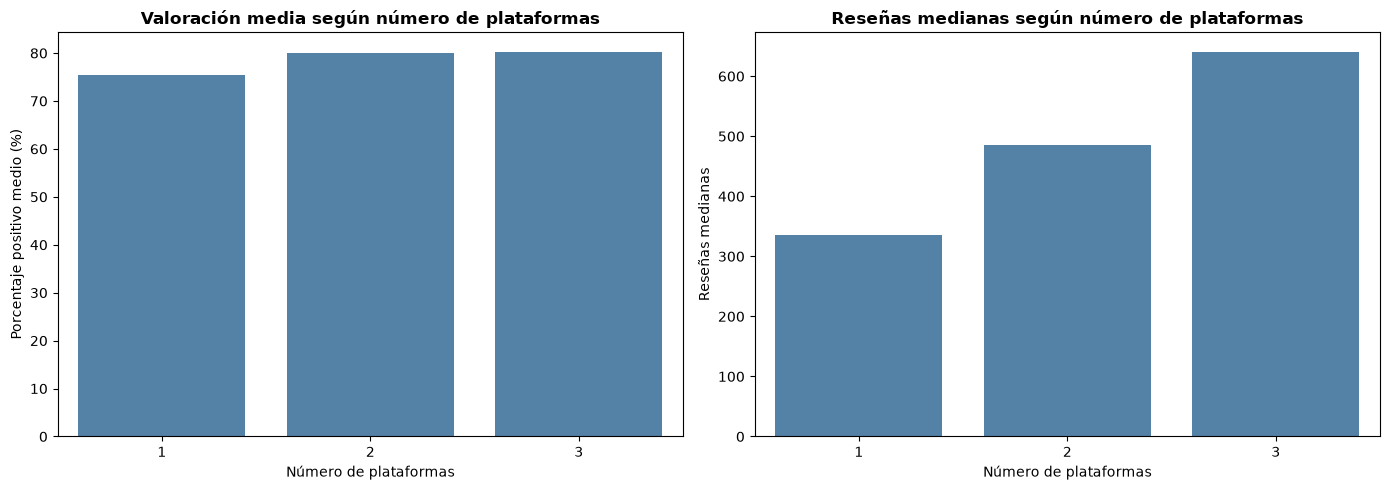

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=tabla_plataformas.reset_index(), x='n_plataformas',
            y='porcentaje_positivo_medio', ax=axes[0], color='steelblue')
axes[0].set_title('Valoración media según número de plataformas',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de plataformas', fontsize=10)
axes[0].set_ylabel('Porcentaje positivo medio (%)', fontsize=10)

sns.barplot(data=tabla_plataformas.reset_index(), x='n_plataformas',
            y='resenas_medianas', ax=axes[1], color='steelblue')
axes[1].set_title('Reseñas medianas según número de plataformas',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de plataformas', fontsize=10)
axes[1].set_ylabel('Reseñas medianas', fontsize=10)

plt.tight_layout()
plt.show()

**Conclusión.** Sí existe relación. Los juegos que solo salen en una plataforma tienen 75.36% de
reseñas positivas y una mediana de 335 reseñas, mientras que los que salen en las tres llegan a 80.31%
y 641 reseñas medianas. La mayoría del catálogo (15784 juegos) se publica en una sola plataforma.

## 5. ¿Cómo han evolucionado los lanzamientos y los precios a lo largo de los años?

In [40]:
evolucion_completa = data.groupby('anio_lanzamiento').agg(
    juegos=('name', 'count'),
    precio_mediano=('precio_usd', 'median'),
    porcentaje_positivo_medio=('porcentaje_positivo', 'mean')
).round(2)

evolucion_completa.tail(15)

,juegos,precio_mediano,porcentaje_positivo_medio
anio_lanzamiento,,,
2012.0,309,7.99,76.73
2013.0,433,9.99,75.71
2014.0,1158,5.99,71.98
2015.0,1468,4.99,72.62
2016.0,1938,4.99,73.93
2017.0,1890,4.49,73.69
2018.0,1825,2.99,73.84
2019.0,1549,4.99,77.13
2020.0,2168,2.99,78.38


In [41]:
anio_max = evolucion_completa['juegos'].idxmax()
print(f"Año con más lanzamientos: {int(anio_max)} ({evolucion_completa['juegos'].max()} juegos)")
print(f"Precio mediano en 2015: {evolucion_completa.loc[2015, 'precio_mediano']} USD")
print(f"Precio mediano en 2025: {evolucion_completa.loc[2025, 'precio_mediano']} USD")

Año con más lanzamientos: 2021 (2267 juegos)
Precio mediano en 2015: 4.99 USD
Precio mediano en 2025: 9.99 USD


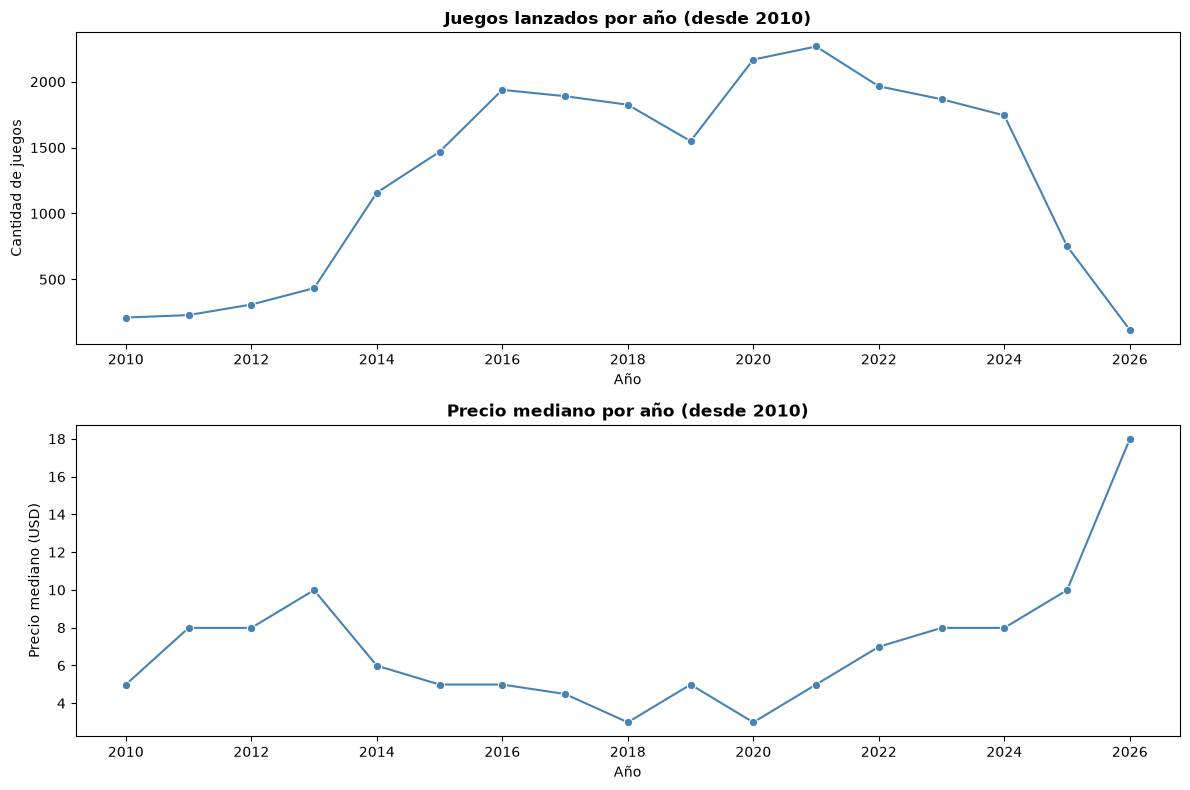

In [42]:
reciente = evolucion_completa.loc[2010:].reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.lineplot(data=reciente, x='anio_lanzamiento', y='juegos',
             marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Juegos lanzados por año (desde 2010)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año', fontsize=10)
axes[0].set_ylabel('Cantidad de juegos', fontsize=10)

sns.lineplot(data=reciente, x='anio_lanzamiento', y='precio_mediano',
             marker='o', ax=axes[1], color='steelblue')
axes[1].set_title('Precio mediano por año (desde 2010)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año', fontsize=10)
axes[1].set_ylabel('Precio mediano (USD)', fontsize=10)

plt.tight_layout()
plt.show()

**Conclusión.** La cantidad de lanzamientos creció con fuerza hasta alcanzar su máximo en 2021 con
2267 juegos y después desciende. Esa caída final no puede leerse como una tendencia real, porque la
fecha más reciente del dataset es agosto de 2026 y los años 2025 (752 juegos) y 2026 (117) están
incompletos. El precio mediano siguió el camino contrario: bajó hasta 2.99 USD en 2018 y 2020 y desde
entonces subió hasta 9.99 USD en 2025, es decir se duplicó respecto a los 4.99 USD de 2015. El
porcentaje positivo medio también sube de forma sostenida, de 71.98% en 2014 a 82.24% en 2025, aunque
en los años más recientes influye que los juegos con pocas reseñas todavía no se han acumulado.